# Exploratory Data Analysis

### Import Libraries

In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

### Load the Dataset

In [80]:
df = pd.read_csv("../data/processed/final_hotel_bookings.csv")

## Booking Analysis

In [81]:
monthly_bookings = (

    df.groupby("arrival_date_month")

    .size()

    .reset_index(name="Bookings")

)

monthly_bookings

,arrival_date_month,Bookings
0,April,7900
1,August,11238
2,December,5112
3,February,6083
4,January,4685
5,July,10043
6,June,7756
7,March,7488
8,May,8344
9,November,4973


### Since month names are not automatically in calendar order, reorder them.

In [82]:
month_order = [

    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"

]

monthly_bookings["arrival_date_month"] = pd.Categorical(

    monthly_bookings["arrival_date_month"],

    categories=month_order,

    ordered=True

)

monthly_bookings = monthly_bookings.sort_values(
    "arrival_date_month"
)

### Plot the monthly booking trend.

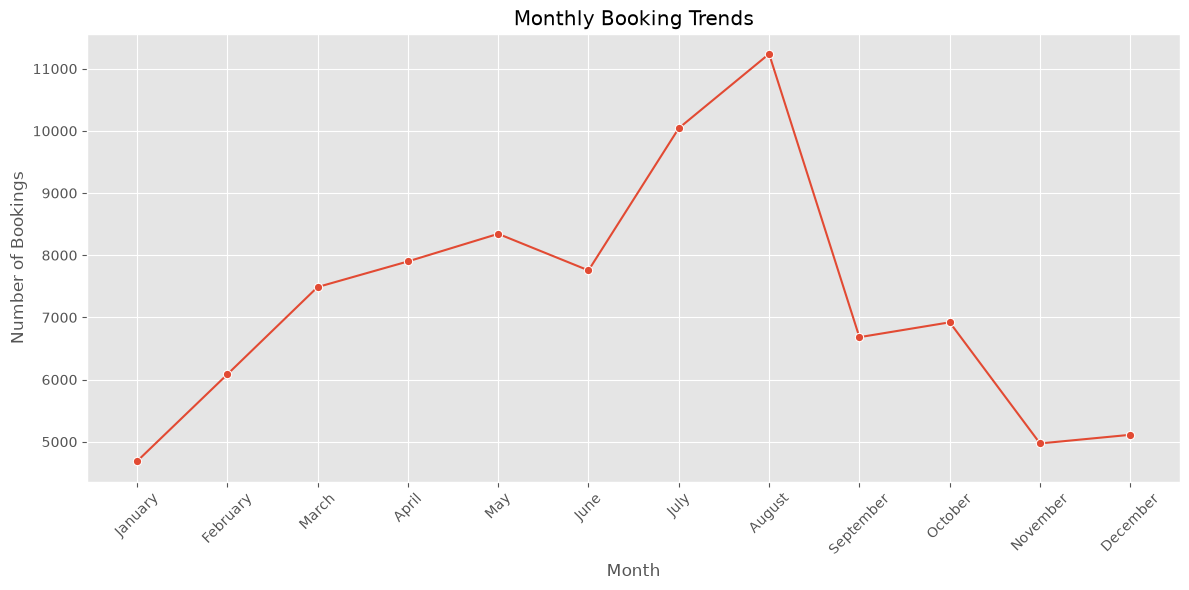

In [83]:
plt.figure(figsize=(12,6))

sns.lineplot(

    data=monthly_bookings,

    x="arrival_date_month",

    y="Bookings",

    marker="o"

)

plt.xticks(rotation=45)

plt.title("Monthly Booking Trends")

plt.xlabel("Month")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/monthly_booking_trend.png",

    dpi=300

)

plt.show()

In [84]:
monthly_bookings

,arrival_date_month,Bookings
4,January,4685
3,February,6083
7,March,7488
0,April,7900
8,May,8344
6,June,7756
5,July,10043
1,August,11238
11,September,6682
10,October,6921


## Business Interpretation

#### The monthly booking trend illustrates seasonal demand patterns throughout the year. Identifying peak and off-peak months enables hotel managers to optimize staffing, promotional campaigns, pricing strategies, and resource allocation to maximize occupancy and revenue.

## Conclusion

#### Monthly booking analysis reveals seasonal fluctuations in hotel demand. These trends provide valuable insights for forecasting future bookings and planning operational resources during both high-demand and low-demand periods.

# Hotel Type Comparison

### Booking Count by Hotel Type

In [85]:
hotel_booking_count = (

    df.groupby("hotel")

    .size()

    .reset_index(name="Bookings")

)

hotel_booking_count

,hotel,Bookings
0,City Hotel,53270
1,Resort Hotel,33955


### Calculate Percentage Share

In [86]:
hotel_booking_count["Percentage"] = (

    hotel_booking_count["Bookings"]

    / hotel_booking_count["Bookings"].sum()

) * 100

hotel_booking_count["Percentage"] = (

    hotel_booking_count["Percentage"]

    .round(2)

)

hotel_booking_count

,hotel,Bookings,Percentage
0,City Hotel,53270,61.07
1,Resort Hotel,33955,38.93


### Bar Chart

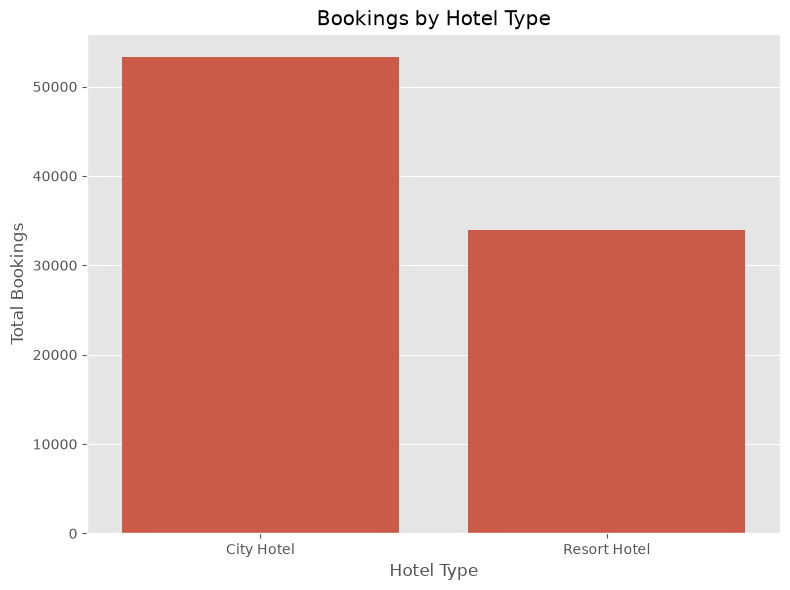

In [87]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=hotel_booking_count,

    x="hotel",

    y="Bookings"

)

plt.title("Bookings by Hotel Type")

plt.xlabel("Hotel Type")

plt.ylabel("Total Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/hotel_type_bookings_bar.png",

    dpi=300

)

plt.show()


### Pie Chart

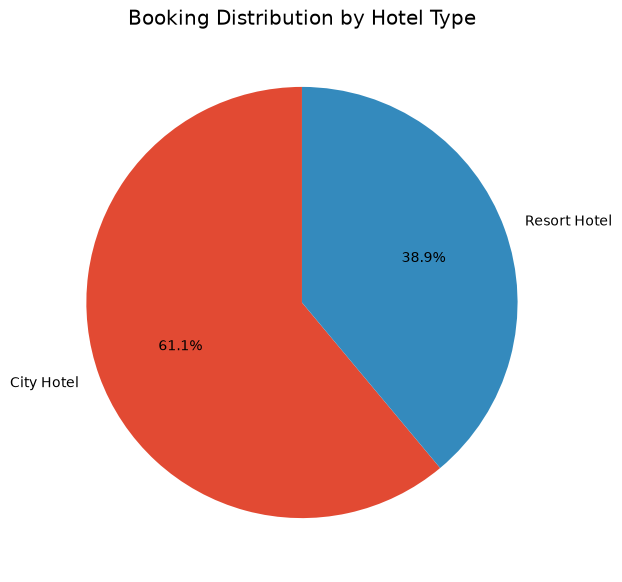

In [88]:
plt.figure(figsize=(7,7))

plt.pie(

    hotel_booking_count["Bookings"],

    labels=hotel_booking_count["hotel"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Booking Distribution by Hotel Type")

plt.savefig(

    "../figures/phase_06/hotel_type_bookings_pie.png",

    dpi=300

)

plt.show()

In [89]:
hotel_booking_count

,hotel,Bookings,Percentage
0,City Hotel,53270,61.07
1,Resort Hotel,33955,38.93


## Business Interpretation

#### Comparing booking volumes between City Hotels and Resort Hotels helps identify customer preferences. If one hotel type consistently attracts a larger share of bookings, hotel management can investigate the underlying factors, such as location, pricing, amenities, or seasonal demand, to improve occupancy and marketing strategies.

## Conclusion

#### Hotel type comparison revealed the distribution of bookings between City Hotels and Resort Hotels. The analysis highlights customer preferences and provides insights that support operational planning, investment decisions, and targeted marketing initiatives.

# Booking Lead Time Analysis

### Descriptive Statistics

In [90]:
lead_time_summary = df["lead_time"].describe()

lead_time_summary

count    87225.000000
mean        78.444918
std         81.052481
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        296.000000
Name: lead_time, dtype: float64

### Additional Statistics

In [91]:
lead_time_stats = pd.DataFrame({

    "Statistic": [

        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"

    ],

    "Value": [

        df["lead_time"].min(),

        df["lead_time"].max(),

        round(df["lead_time"].mean(), 2),

        df["lead_time"].median(),

        round(df["lead_time"].std(), 2)

    ]

})

lead_time_stats

,Statistic,Value
0,Minimum,0.00
1,Maximum,296.00
2,Mean,78.44
3,Median,49.00
4,Standard Deviation,81.05


### Histogram

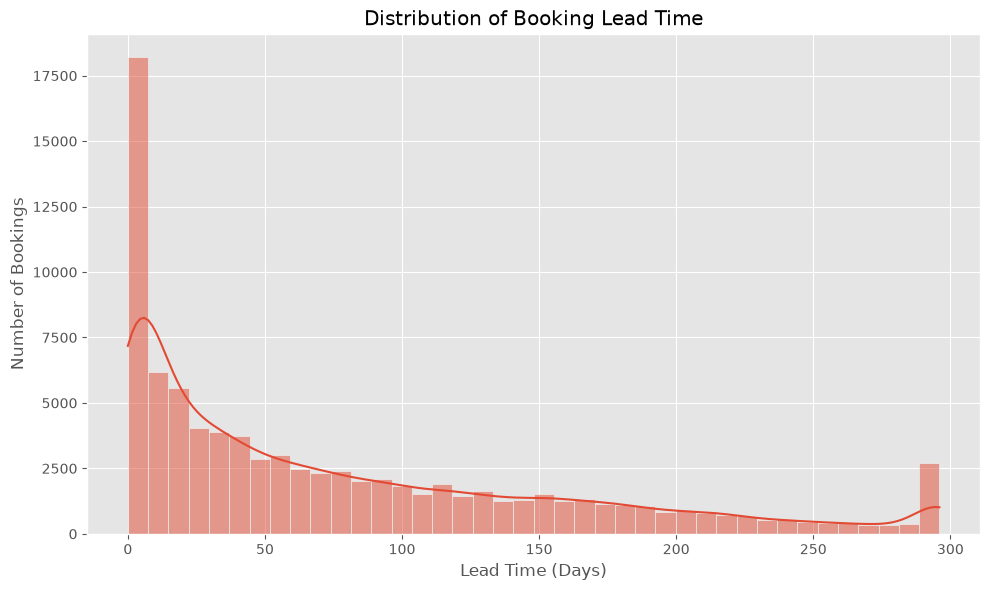

In [92]:
plt.figure(figsize=(10,6))

sns.histplot(

    data=df,

    x="lead_time",

    bins=40,

    kde=True

)

plt.title("Distribution of Booking Lead Time")

plt.xlabel("Lead Time (Days)")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/lead_time_histogram.png",

    dpi=300

)

plt.show()

### Box Plot

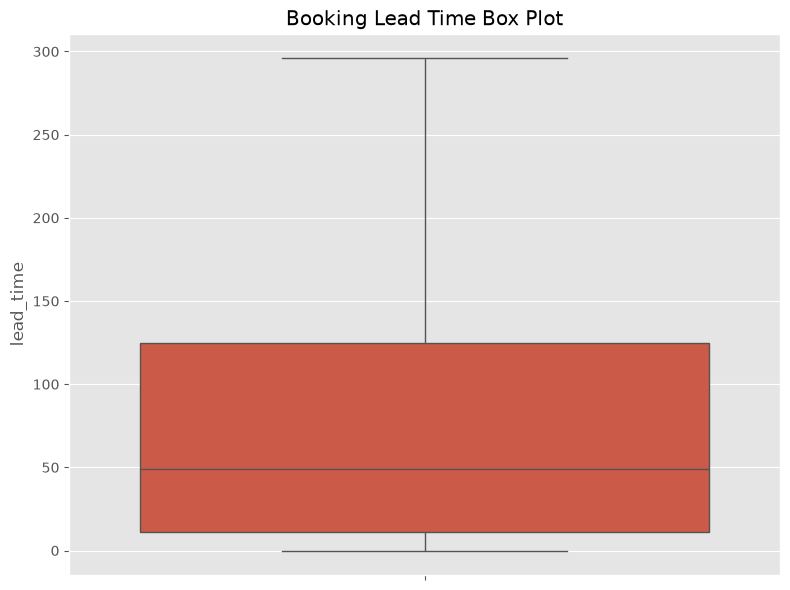

In [93]:
plt.figure(figsize=(8,6))

sns.boxplot(

    y=df["lead_time"]

)

plt.title("Booking Lead Time Box Plot")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/lead_time_boxplot.png",

    dpi=300

)

plt.show()

### Booking Lead Time Categories

In [94]:
bins = [-1, 7, 30, 90, 180, df["lead_time"].max()]

labels = [

    "0-7 Days",

    "8-30 Days",

    "31-90 Days",

    "91-180 Days",

    "180+ Days"

]

df["lead_time_category"] = pd.cut(

    df["lead_time"],

    bins=bins,

    labels=labels

)

### Category Summary

In [95]:
lead_time_category = (

    df["lead_time_category"]

    .value_counts()

    .sort_index()

    .reset_index()

)

lead_time_category.columns = [

    "Lead Time Category",

    "Bookings"

]

lead_time_category

,Lead Time Category,Bookings
0,0-7 Days,18200
1,8-30 Days,16325
2,31-90 Days,22720
3,91-180 Days,18224
4,180+ Days,11756


### Lead Time Category Bar Chart

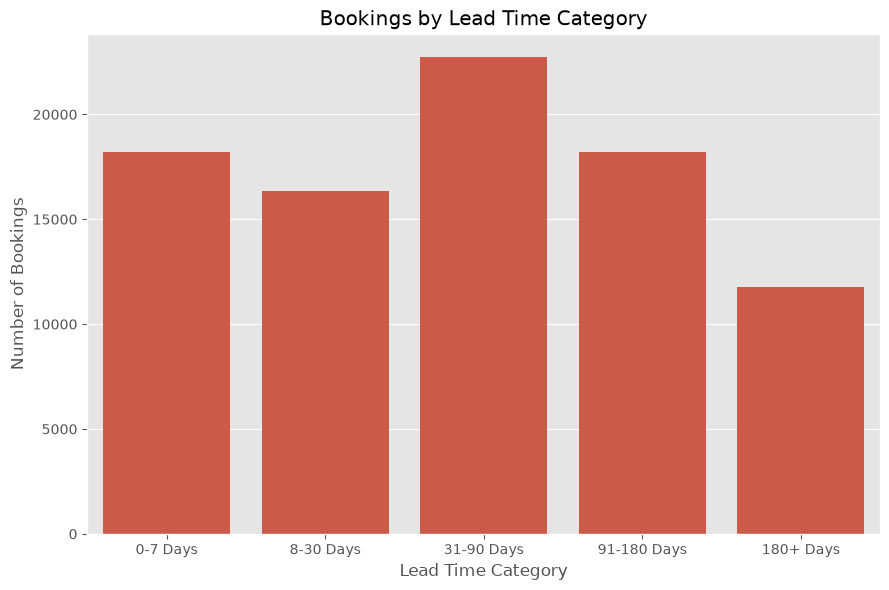

In [96]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=lead_time_category,

    x="Lead Time Category",

    y="Bookings"

)

plt.title("Bookings by Lead Time Category")

plt.xlabel("Lead Time Category")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/lead_time_category_bar.png",

    dpi=300

)

plt.show()

In [97]:
lead_time_category

,Lead Time Category,Bookings
0,0-7 Days,18200
1,8-30 Days,16325
2,31-90 Days,22720
3,91-180 Days,18224
4,180+ Days,11756


## Business Interpretation

#### Lead time analysis provides insights into customer booking behavior by showing how far in advance reservations are made. Hotels can use this information to optimize pricing strategies, forecast demand, launch early booking promotions, and manage room availability more effectively. Understanding booking windows also supports better staffing and operational planning.

## Conclusion

#### Booking lead time analysis revealed the distribution of reservation timing across different booking windows. The histogram, box plot, and categorized booking ranges provide a comprehensive understanding of customer booking patterns, enabling data-driven pricing and demand management decisions.

# Seasonal Booking Trends

### Create Season Feature

In [98]:
season_mapping = {

    "December": "Winter",
    "January": "Winter",
    "February": "Winter",

    "March": "Spring",
    "April": "Spring",
    "May": "Spring",

    "June": "Summer",
    "July": "Summer",
    "August": "Summer",

    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn"

}

df["season"] = df["arrival_date_month"].map(
    season_mapping
)

### Seasonal Booking Summary

In [99]:
seasonal_bookings = (

    df.groupby("season")

    .size()

    .reset_index(name="Bookings")

)

season_order = [

    "Spring",
    "Summer",
    "Autumn",
    "Winter"

]

seasonal_bookings["season"] = pd.Categorical(

    seasonal_bookings["season"],

    categories=season_order,

    ordered=True

)

seasonal_bookings = seasonal_bookings.sort_values(
    "season"
)

seasonal_bookings

,season,Bookings
1,Spring,23732
2,Summer,29037
0,Autumn,18576
3,Winter,15880


### Calculate Percentage

In [100]:
seasonal_bookings["Percentage"] = (

    seasonal_bookings["Bookings"]

    / seasonal_bookings["Bookings"].sum()

) * 100

seasonal_bookings["Percentage"] = (

    seasonal_bookings["Percentage"]

    .round(2)

)

seasonal_bookings

,season,Bookings,Percentage
1,Spring,23732,27.21
2,Summer,29037,33.29
0,Autumn,18576,21.30
3,Winter,15880,18.21


### Bar Chart

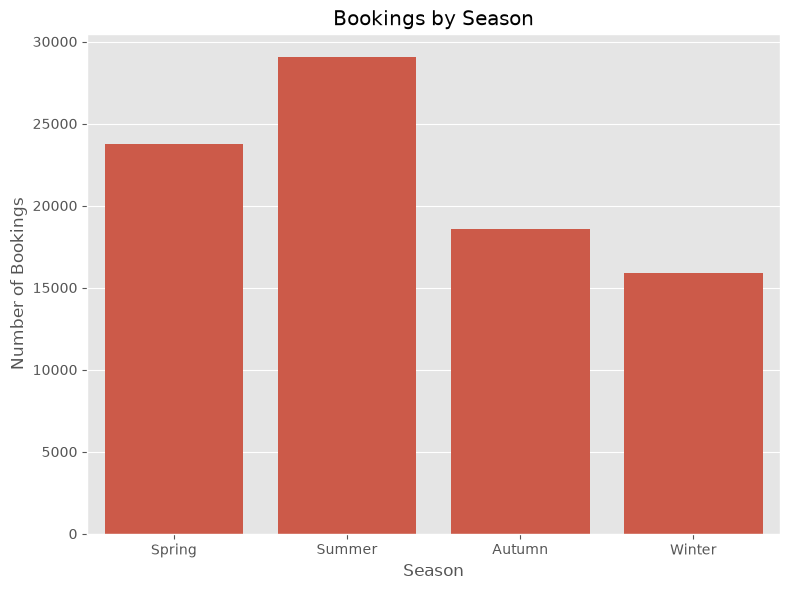

In [101]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=seasonal_bookings,

    x="season",

    y="Bookings"

)

plt.title("Bookings by Season")

plt.xlabel("Season")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/seasonal_bookings_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

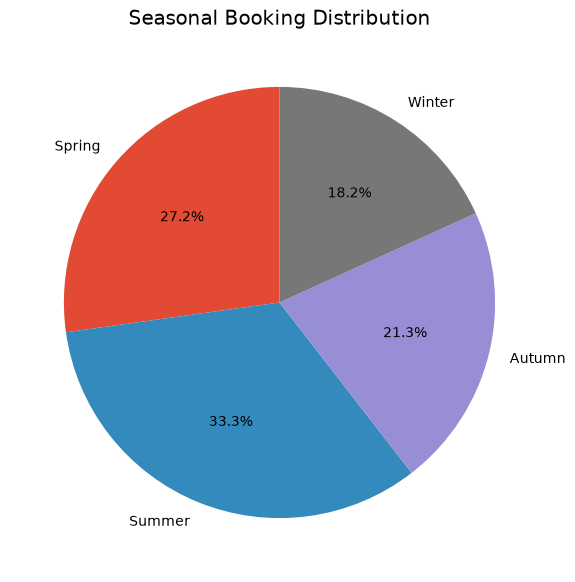

In [102]:
plt.figure(figsize=(7,7))

plt.pie(

    seasonal_bookings["Bookings"],

    labels=seasonal_bookings["season"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Seasonal Booking Distribution")

plt.savefig(

    "../figures/phase_06/seasonal_bookings_pie.png",

    dpi=300

)

plt.show()

### Hotel Type vs Season

In [103]:
hotel_season = pd.crosstab(

    df["season"],

    df["hotel"]

)

hotel_season

hotel,City Hotel,Resort Hotel
season,,
Autumn,11351,7225
Spring,15307,8425
Summer,17299,11738
Winter,9313,6567


### Stacked Bar Chart

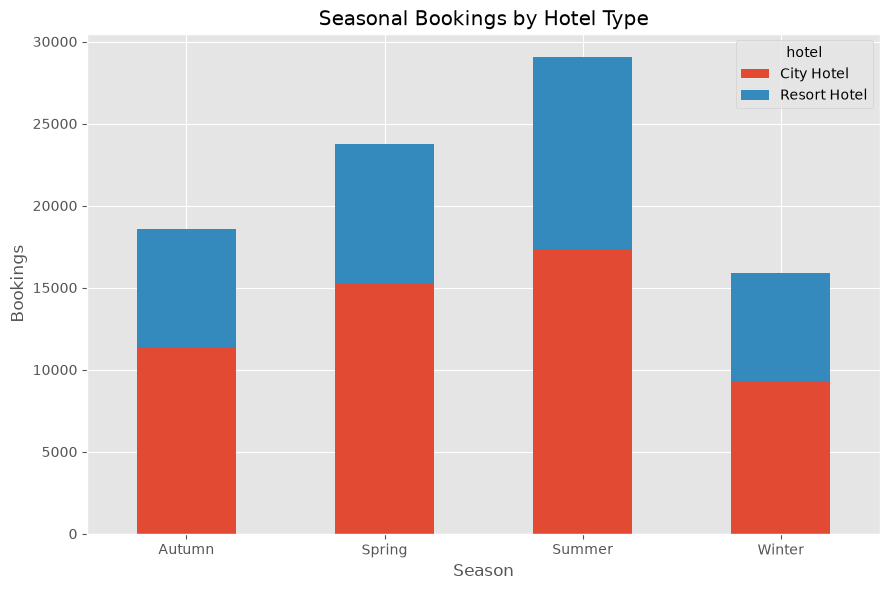

In [104]:
hotel_season.plot(

    kind="bar",

    stacked=True,

    figsize=(9,6)

)

plt.title("Seasonal Bookings by Hotel Type")

plt.xlabel("Season")

plt.ylabel("Bookings")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/season_hoteltype_stacked.png",

    dpi=300

)

plt.show()

In [105]:
seasonal_bookings

,season,Bookings,Percentage
1,Spring,23732,27.21
2,Summer,29037,33.29
0,Autumn,18576,21.30
3,Winter,15880,18.21


## Business Interpretation

#### Seasonal booking analysis identifies peak and off-peak demand periods throughout the year. Understanding seasonal booking behavior enables hotel management to optimize pricing strategies, staffing levels, inventory planning, promotional campaigns, and resource allocation. Comparing hotel types across seasons also provides insights into customer preferences during different times of the year.

## Conclusion

#### Seasonal booking trend analysis revealed how hotel demand varies throughout the year. The bar chart, pie chart, and hotel-type comparison highlight seasonal booking patterns and customer preferences, providing valuable information for strategic planning and revenue optimization.

# Customer Type Distribution

In [106]:
# summary

customer_type_summary = (

    df.groupby("customer_type")

    .size()

    .reset_index(name="Bookings")

)

customer_type_summary

,customer_type,Bookings
0,Contract,3135
1,Group,541
2,Transient,71862
3,Transient-Party,11687


### Calculate Percentage

In [107]:
customer_type_summary["Percentage"] = (

    customer_type_summary["Bookings"]

    / customer_type_summary["Bookings"].sum()

) * 100

customer_type_summary["Percentage"] = (

    customer_type_summary["Percentage"]

    .round(2)

)

customer_type_summary

,customer_type,Bookings,Percentage
0,Contract,3135,3.59
1,Group,541,0.62
2,Transient,71862,82.39
3,Transient-Party,11687,13.40


### Sort by Bookings

In [108]:
customer_type_summary = customer_type_summary.sort_values(

    by="Bookings",

    ascending=False

)

customer_type_summary

,customer_type,Bookings,Percentage
2,Transient,71862,82.39
3,Transient-Party,11687,13.40
0,Contract,3135,3.59
1,Group,541,0.62


### Bar Chart

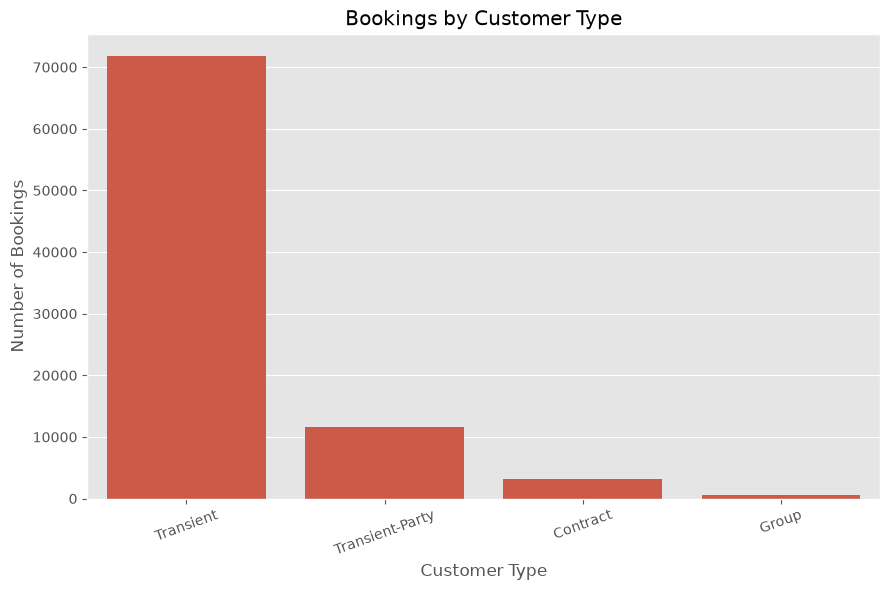

In [109]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=customer_type_summary,

    x="customer_type",

    y="Bookings"

)

plt.title("Bookings by Customer Type")

plt.xlabel("Customer Type")

plt.ylabel("Number of Bookings")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/customer_type_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

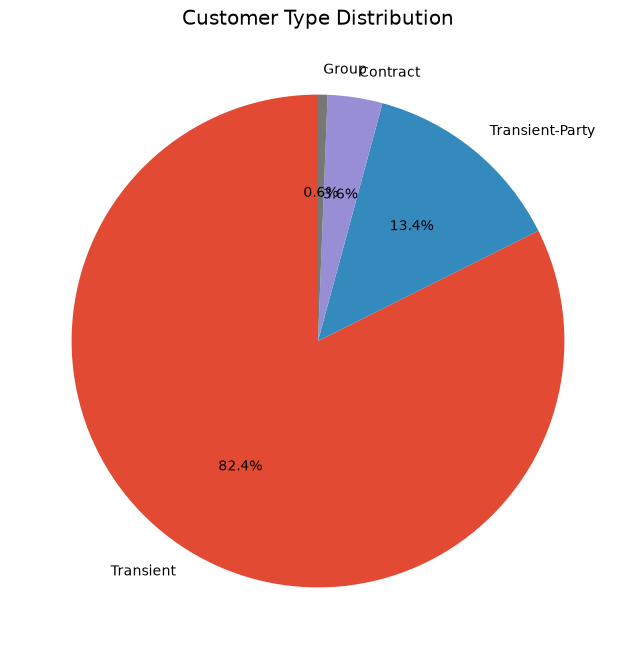

In [110]:
plt.figure(figsize=(8,8))

plt.pie(

    customer_type_summary["Bookings"],

    labels=customer_type_summary["customer_type"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Customer Type Distribution")

plt.savefig(

    "../figures/phase_06/customer_type_pie.png",

    dpi=300

)

plt.show()

In [111]:
customer_type_summary

,customer_type,Bookings,Percentage
2,Transient,71862,82.39
3,Transient-Party,11687,13.40
0,Contract,3135,3.59
1,Group,541,0.62


### Identify the Largest Customer Segment

In [112]:
top_customer = customer_type_summary.iloc[0]

print("Top Customer Type :", top_customer["customer_type"])

print("Bookings :", top_customer["Bookings"])

print("Percentage :", top_customer["Percentage"], "%")

Top Customer Type : Transient
Bookings : 71862
Percentage : 82.39 %


## Business Interpretation

#### Customer type distribution provides insight into the composition of the hotel's customer base. A high proportion of transient customers may indicate dependence on individual travelers, while a larger share of contract or group customers suggests stronger corporate partnerships or organized travel demand. These insights help hotels tailor marketing campaigns, pricing strategies, and loyalty programs for different customer segments.

## Conclusion

#### Customer type analysis revealed the distribution of bookings across different customer categories. The results identify the dominant customer segment and provide valuable information for customer relationship management, marketing strategies, and business planning.

# Country-wise Bookings

### Country-wise Booking Summary

In [113]:
country_bookings = (

    df.groupby("country")

    .size()

    .reset_index(name="Bookings")

)

country_bookings = country_bookings.sort_values(

    by="Bookings",

    ascending=False

)

country_bookings.head(10)

,country,Bookings
135,PRT,27351
59,GBR,10423
56,FRA,8823
51,ESP,7244
43,DEU,5385
81,ITA,3061
76,IRL,3015
15,BEL,2081
25,BRA,1993
123,NLD,1910


### Top 10 Countries

In [114]:
top10_countries = country_bookings.head(10)

top10_countries

,country,Bookings
135,PRT,27351
59,GBR,10423
56,FRA,8823
51,ESP,7244
43,DEU,5385
81,ITA,3061
76,IRL,3015
15,BEL,2081
25,BRA,1993
123,NLD,1910


### Percentage Contribution

In [115]:
top10_countries["Percentage"] = (

    top10_countries["Bookings"]

    / df.shape[0]

) * 100

top10_countries["Percentage"] = (

    top10_countries["Percentage"]

    .round(2)

)

top10_countries

,country,Bookings,Percentage
135,PRT,27351,31.36
59,GBR,10423,11.95
56,FRA,8823,10.12
51,ESP,7244,8.30
43,DEU,5385,6.17
81,ITA,3061,3.51
76,IRL,3015,3.46
15,BEL,2081,2.39
25,BRA,1993,2.28
123,NLD,1910,2.19


### Horizontal Bar Chart

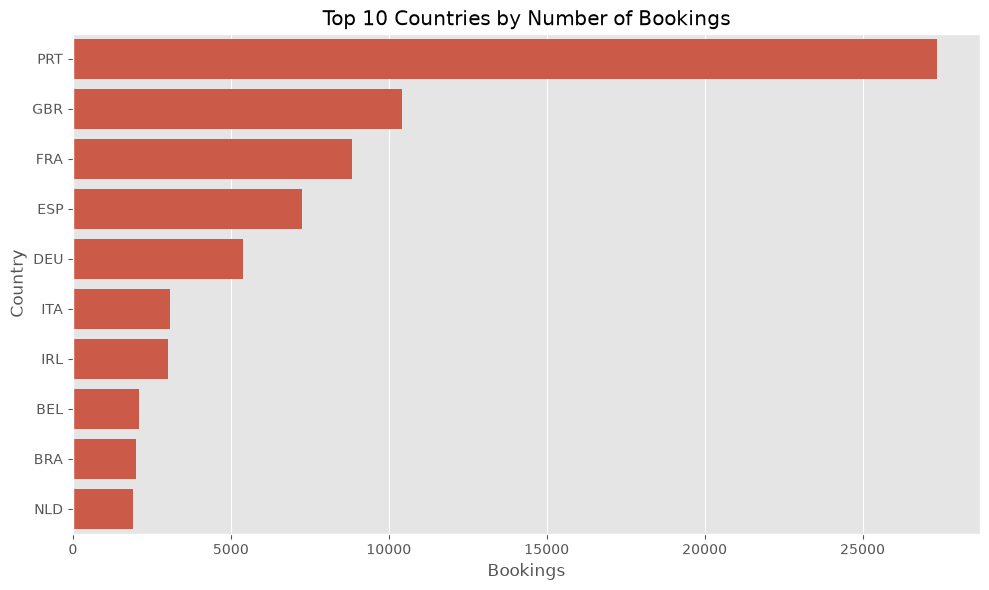

In [116]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=top10_countries,

    y="country",

    x="Bookings"

)

plt.title("Top 10 Countries by Number of Bookings")

plt.xlabel("Bookings")

plt.ylabel("Country")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/top10_country_bookings_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

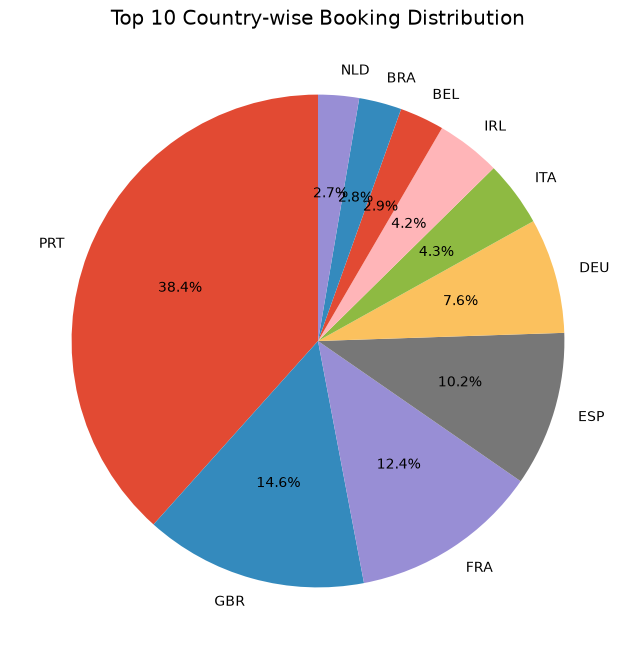

In [117]:
plt.figure(figsize=(8,8))

plt.pie(

    top10_countries["Bookings"],

    labels=top10_countries["country"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Top 10 Country-wise Booking Distribution")

plt.savefig(

    "../figures/phase_06/top10_country_bookings_pie.png",

    dpi=300

)

plt.show()

In [118]:
top10_countries

,country,Bookings,Percentage
135,PRT,27351,31.36
59,GBR,10423,11.95
56,FRA,8823,10.12
51,ESP,7244,8.30
43,DEU,5385,6.17
81,ITA,3061,3.51
76,IRL,3015,3.46
15,BEL,2081,2.39
25,BRA,1993,2.28
123,NLD,1910,2.19


### Top Booking Country

In [119]:
top_country = top10_countries.iloc[0]

print("Top Country :", top_country["country"])

print("Bookings :", top_country["Bookings"])

print("Percentage :", top_country["Percentage"], "%")

Top Country : PRT
Bookings : 27351
Percentage : 31.36 %


## Business Interpretation

#### Country-wise booking analysis identifies the major geographic markets contributing to hotel reservations. Recognizing the top booking countries helps hotel management develop targeted marketing campaigns, improve multilingual customer support, establish partnerships with travel agencies, and optimize pricing strategies for high-demand regions.

## Conclusion

#### Country-wise booking analysis highlighted the top international markets contributing to hotel reservations. The results provide valuable insights into customer demographics and support strategic decisions related to marketing, customer service, and business expansion.

# Repeat Guest Analysis

### Create Guest Category

In [120]:
df["guest_type"] = df["is_repeated_guest"].map({

    0: "First-Time Guest",

    1: "Repeat Guest"

})

### Guest Type Summary

In [121]:
repeat_guest_summary = (

    df.groupby("guest_type")

    .size()

    .reset_index(name="Bookings")

)

repeat_guest_summary

,guest_type,Bookings


### Calculate Percentage

In [122]:
repeat_guest_summary["Percentage"] = (

    repeat_guest_summary["Bookings"]

    / repeat_guest_summary["Bookings"].sum()

) * 100

repeat_guest_summary["Percentage"] = (

    repeat_guest_summary["Percentage"]

    .round(2)

)

repeat_guest_summary

,guest_type,Bookings,Percentage


### Bar Chart

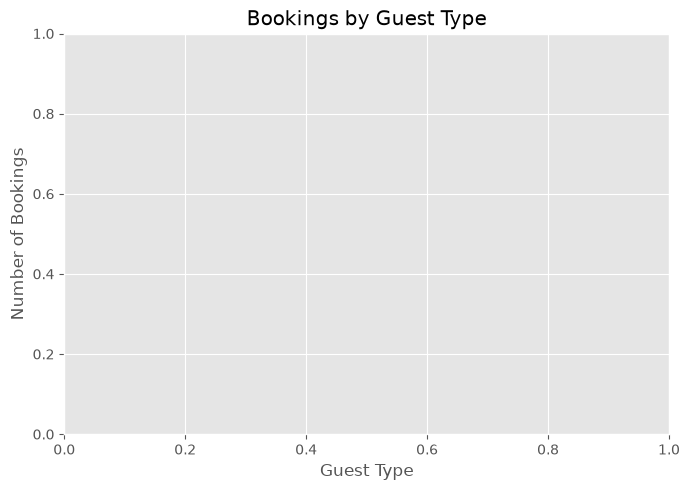

In [123]:
plt.figure(figsize=(7,5))

sns.barplot(

    data=repeat_guest_summary,

    x="guest_type",

    y="Bookings"

)

plt.title("Bookings by Guest Type")

plt.xlabel("Guest Type")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/repeat_guest_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

ValueError: All wedge sizes are zero

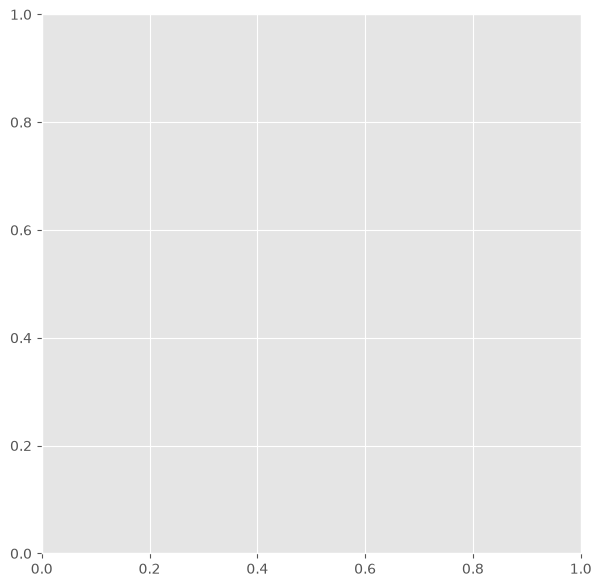

In [124]:
plt.figure(figsize=(7,7))

plt.pie(

    repeat_guest_summary["Bookings"],

    labels=repeat_guest_summary["guest_type"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Repeat Guest Distribution")

plt.savefig(

    "../figures/phase_06/repeat_guest_pie.png",

    dpi=300

)

plt.show()

### Cancellation Rate by Guest Type

In [125]:
guest_cancellation = pd.crosstab(

    df["guest_type"],

    df["is_canceled"],

    normalize="index"

) * 100

guest_cancellation.round(2)

is_canceled
guest_type


### Stacked Bar Chart

TypeError: no numeric data to plot

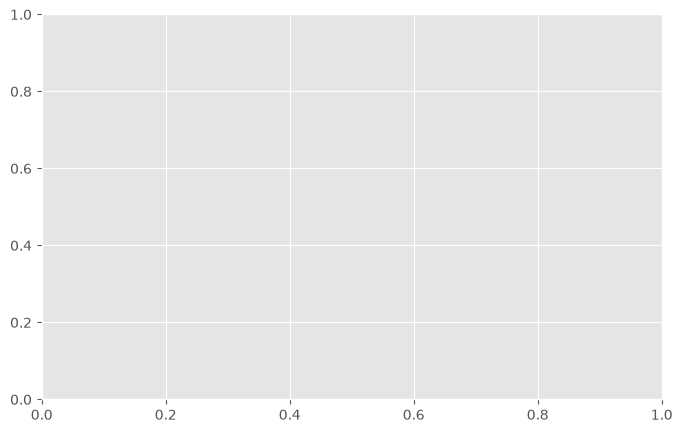

In [126]:
guest_cancellation.plot(

    kind="bar",

    stacked=True,

    figsize=(8,5)

)

plt.title("Cancellation Rate by Guest Type")

plt.xlabel("Guest Type")

plt.ylabel("Percentage")

plt.legend(

    title="Cancelled",

    labels=["Not Cancelled", "Cancelled"]

)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/repeat_guest_cancellation.png",

    dpi=300

)

plt.show()

In [127]:
repeat_guest_summary

,guest_type,Bookings,Percentage


## Business Interpretation

#### Repeat guest analysis measures customer loyalty by comparing first-time and returning guests. A higher proportion of repeat guests often indicates strong customer satisfaction and successful retention strategies. Comparing cancellation behavior between the two groups also helps identify whether loyal customers are more reliable in completing their bookings.

## Conclusion

#### Repeat guest analysis revealed the proportion of first-time and returning customers along with their cancellation behavior. These insights support customer retention strategies, loyalty program evaluation, and long-term revenue planning.

# Cancellation Analysis

### Overall Cancellation Rate

In [128]:
cancellation_summary = (

    df.groupby("is_canceled")

    .size()

    .reset_index(name="Bookings")

)

cancellation_summary

,is_canceled,Bookings
0,False,63220
1,True,24005


### Rename Values

In [129]:
cancellation_summary["Status"] = cancellation_summary["is_canceled"].map({

    0: "Not Cancelled",

    1: "Cancelled"

})

cancellation_summary

,is_canceled,Bookings,Status
0,False,63220,NaN
1,True,24005,NaN


### Calculate Percentage

In [130]:
cancellation_summary["Percentage"] = (

    cancellation_summary["Bookings"]

    / cancellation_summary["Bookings"].sum()

) * 100

cancellation_summary["Percentage"] = (

    cancellation_summary["Percentage"]

    .round(2)

)

cancellation_summary

,is_canceled,Bookings,Status,Percentage
0,False,63220,NaN,72.48
1,True,24005,NaN,27.52


### Bar Chart

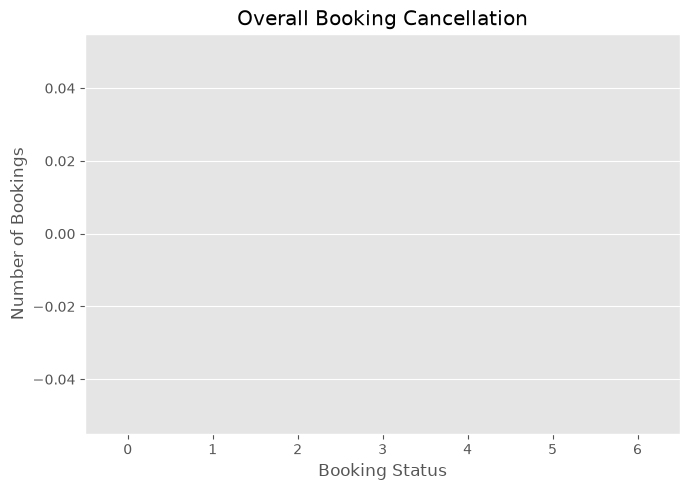

In [131]:
plt.figure(figsize=(7,5))

sns.barplot(

    data=cancellation_summary,

    x="Status",

    y="Bookings"

)

plt.title("Overall Booking Cancellation")

plt.xlabel("Booking Status")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/overall_cancellation_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

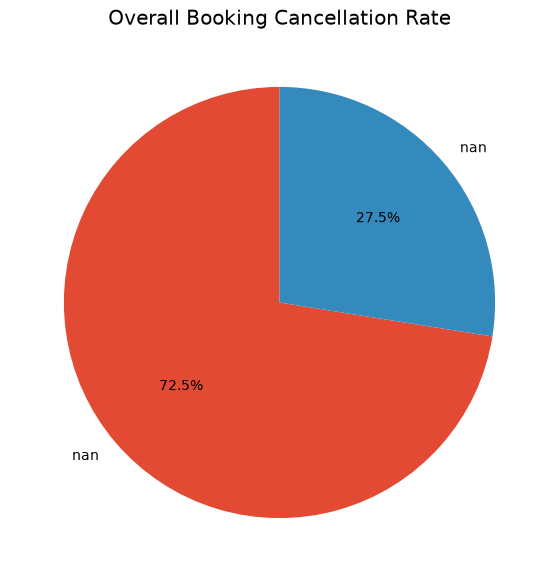

In [132]:
plt.figure(figsize=(7,7))

plt.pie(

    cancellation_summary["Bookings"],

    labels=cancellation_summary["Status"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Overall Booking Cancellation Rate")

plt.savefig(

    "../figures/phase_06/overall_cancellation_pie.png",

    dpi=300

)

plt.show()

### KPI Summary

In [133]:
total_bookings = len(df)

cancelled = df["is_canceled"].sum()

completed = total_bookings - cancelled

cancellation_rate = (

    cancelled / total_bookings

) * 100

print(f"Total Bookings      : {total_bookings}")

print(f"Completed Bookings  : {completed}")

print(f"Cancelled Bookings  : {cancelled}")

print(f"Cancellation Rate   : {cancellation_rate:.2f}%")

Total Bookings      : 87225
Completed Bookings  : 63220
Cancelled Bookings  : 24005
Cancellation Rate   : 27.52%


In [134]:
cancellation_summary

,is_canceled,Bookings,Status,Percentage
0,False,63220,NaN,72.48
1,True,24005,NaN,27.52


## Business Interpretation

#### The overall cancellation rate provides a high-level measure of booking reliability. A high cancellation rate may indicate revenue leakage, inaccurate demand forecasting, or ineffective booking policies. Monitoring this KPI helps hotel management evaluate operational performance and implement strategies such as flexible pricing, deposit requirements, or targeted cancellation policies.

## Conclusion

#### The overall cancellation analysis quantified the proportion of completed and cancelled bookings. This KPI serves as a foundation for deeper analyses, including cancellation behavior by hotel type, market segment, and booking lead time.

# Cancellation by Hotel Type

### Create Cancellation Summary

In [135]:
hotel_cancellation = pd.crosstab(

    df["hotel"],

    df["is_canceled"]

)

hotel_cancellation.columns = [

    "Not Cancelled",

    "Cancelled"

]

hotel_cancellation

,Not Cancelled,Cancelled
hotel,,
City Hotel,37239,16031
Resort Hotel,25981,7974


### Calculate Cancellation Percentage

In [136]:
hotel_cancellation_percentage = pd.crosstab(

    df["hotel"],

    df["is_canceled"],

    normalize="index"

) * 100

hotel_cancellation_percentage.columns = [

    "Not Cancelled",

    "Cancelled"

]

hotel_cancellation_percentage = hotel_cancellation_percentage.round(2)

hotel_cancellation_percentage

,Not Cancelled,Cancelled
hotel,,
City Hotel,69.91,30.09
Resort Hotel,76.52,23.48


### Stacked Bar Chart

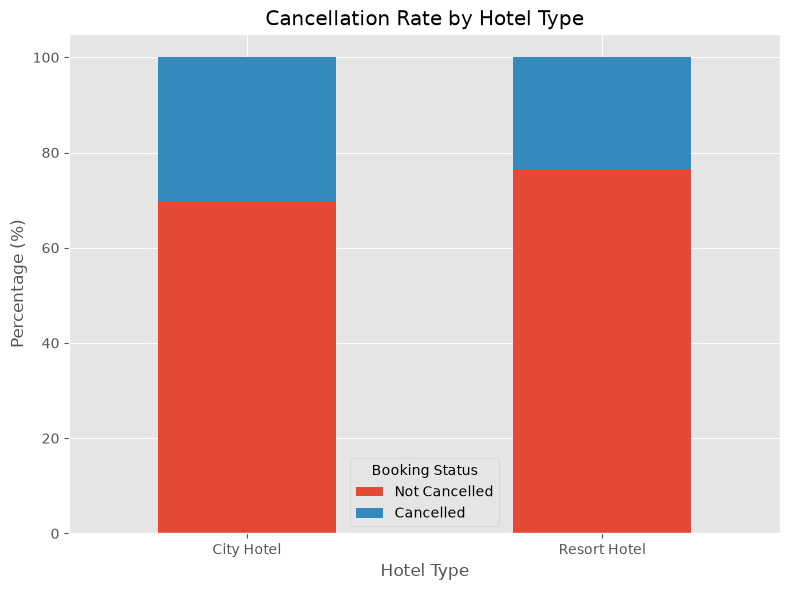

In [137]:
hotel_cancellation_percentage.plot(

    kind="bar",

    stacked=True,

    figsize=(8,6)

)

plt.title("Cancellation Rate by Hotel Type")

plt.xlabel("Hotel Type")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(

    title="Booking Status"

)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/cancellation_by_hotel_stacked.png",

    dpi=300

)

plt.show()

### Grouped Bar Chart

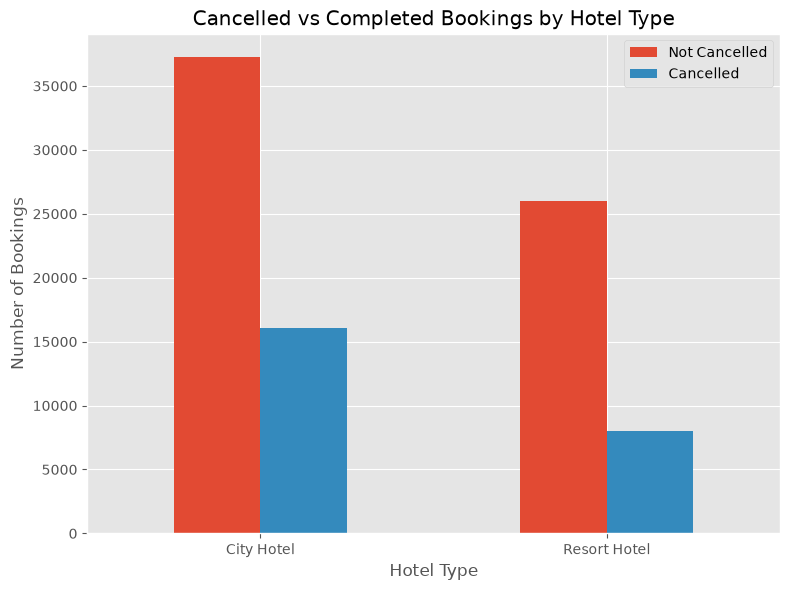

In [138]:
hotel_cancellation.plot(

    kind="bar",

    figsize=(8,6)

)

plt.title("Cancelled vs Completed Bookings by Hotel Type")

plt.xlabel("Hotel Type")

plt.ylabel("Number of Bookings")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/cancellation_by_hotel_grouped.png",

    dpi=300

)

plt.show()

In [139]:
hotel_cancellation_percentage

,Not Cancelled,Cancelled
hotel,,
City Hotel,69.91,30.09
Resort Hotel,76.52,23.48


### Compare Cancellation Rates

In [140]:
highest_cancel = hotel_cancellation_percentage["Cancelled"].idxmax()

highest_rate = hotel_cancellation_percentage["Cancelled"].max()

print("Highest Cancellation Hotel :", highest_cancel)

print("Cancellation Rate :", highest_rate, "%")

Highest Cancellation Hotel : City Hotel
Cancellation Rate : 30.09 %


## Business Interpretation

#### Cancellation behavior differs across hotel types due to differences in customer purpose, booking patterns, pricing strategies, and travel flexibility. Identifying the hotel type with the highest cancellation rate enables management to introduce targeted booking policies, promotional offers, and overbooking strategies to reduce revenue loss.

## Conclusion

#### Cancellation analysis by hotel type compared booking completion and cancellation rates between City Hotels and Resort Hotels. The findings provide actionable insights for hotel managers to improve occupancy forecasting, optimize cancellation policies, and enhance revenue management strategies.

# Cancellation by Market Segment

### Booking Summary by Market Segment

In [141]:
market_segment_summary = pd.crosstab(

    df["market_segment"],

    df["is_canceled"]

)

market_segment_summary.columns = [

    "Not Cancelled",

    "Cancelled"

]

market_segment_summary

,Not Cancelled,Cancelled
market_segment,,
Aviation,181,45
Complementary,607,85
Corporate,3691,509
Direct,10043,1736
Groups,3589,1332
Offline TA/TO,11798,2057
Online TA,33311,18241


### Calculate Cancellation Percentage

In [142]:
market_segment_percentage = pd.crosstab(

    df["market_segment"],

    df["is_canceled"],

    normalize="index"

) * 100

market_segment_percentage.columns = [

    "Not Cancelled",

    "Cancelled"

]

market_segment_percentage = market_segment_percentage.round(2)

market_segment_percentage

,Not Cancelled,Cancelled
market_segment,,
Aviation,80.09,19.91
Complementary,87.72,12.28
Corporate,87.88,12.12
Direct,85.26,14.74
Groups,72.93,27.07
Offline TA/TO,85.15,14.85
Online TA,64.62,35.38


### Sort by Cancellation Rate

In [143]:
market_segment_percentage = market_segment_percentage.sort_values(

    by="Cancelled",

    ascending=False

)

market_segment_percentage

,Not Cancelled,Cancelled
market_segment,,
Online TA,64.62,35.38
Groups,72.93,27.07
Aviation,80.09,19.91
Offline TA/TO,85.15,14.85
Direct,85.26,14.74
Complementary,87.72,12.28
Corporate,87.88,12.12


### Stacked Bar Chart

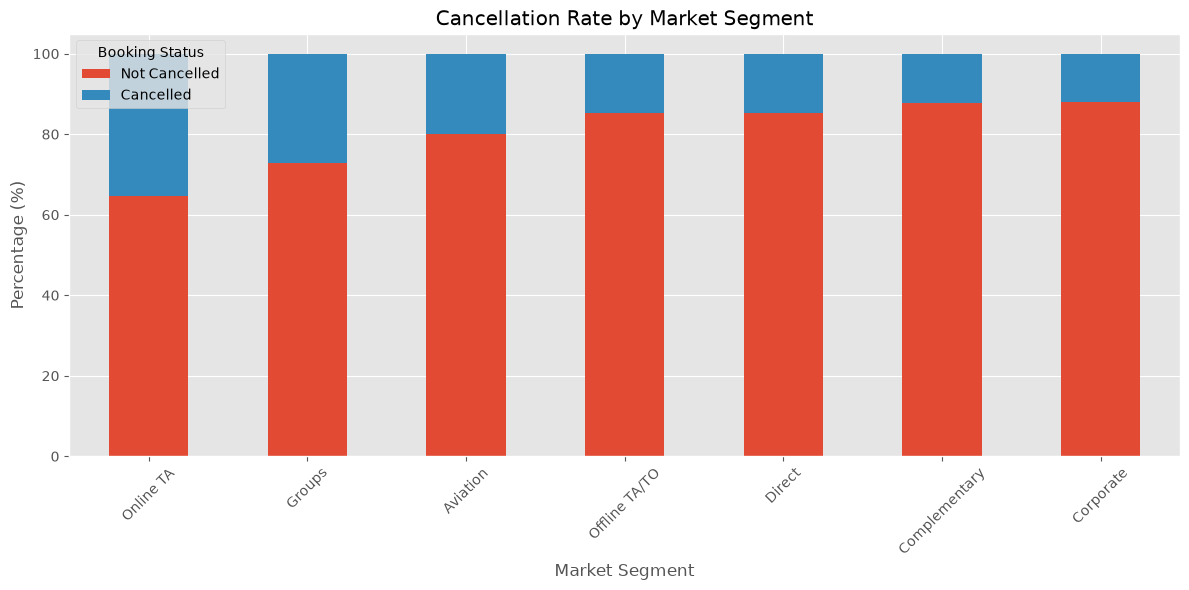

In [144]:
market_segment_percentage.plot(

    kind="bar",

    stacked=True,

    figsize=(12,6)

)

plt.title("Cancellation Rate by Market Segment")

plt.xlabel("Market Segment")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)

plt.legend(title="Booking Status")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/cancellation_market_segment_stacked.png",

    dpi=300

)

plt.show()

### Grouped Bar Chart

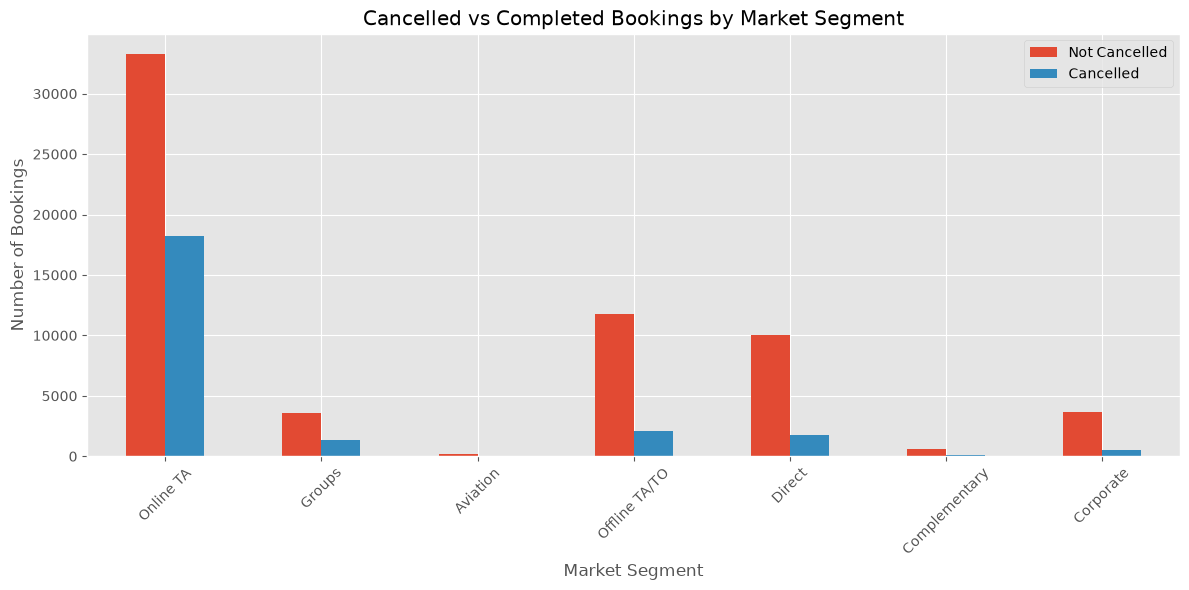

In [145]:
market_segment_summary.loc[

    market_segment_percentage.index

].plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("Cancelled vs Completed Bookings by Market Segment")

plt.xlabel("Market Segment")

plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/cancellation_market_segment_grouped.png",

    dpi=300

)

plt.show()

### Top 5 Highest Cancellation Segments

In [146]:
top5_cancel_segments = market_segment_percentage[

    ["Cancelled"]

].head(5)

top5_cancel_segments

,Cancelled
market_segment,
Online TA,35.38
Groups,27.07
Aviation,19.91
Offline TA/TO,14.85
Direct,14.74


### Horizontal Bar Chart

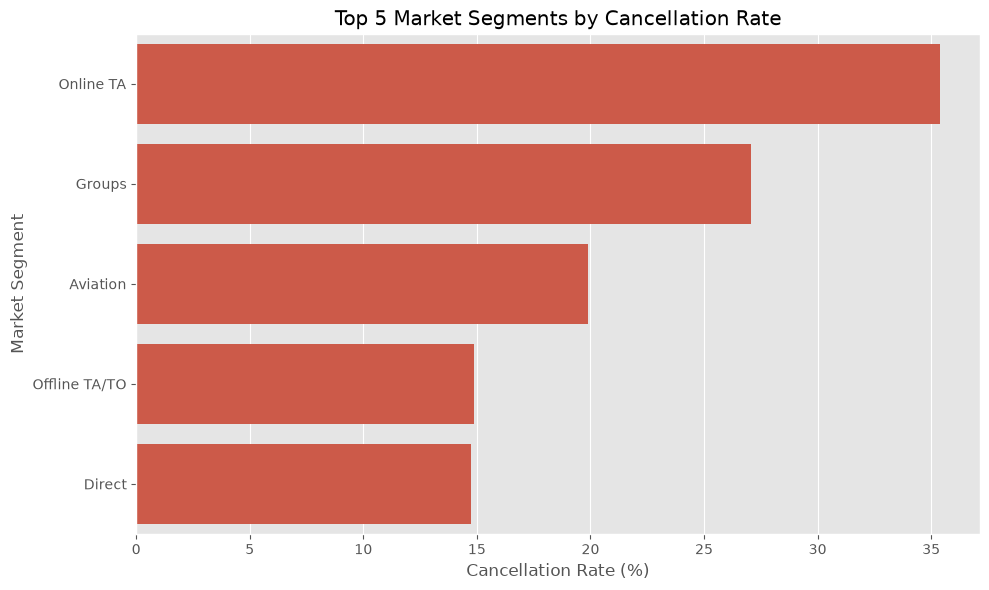

In [147]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=top5_cancel_segments.reset_index(),

    y="market_segment",

    x="Cancelled"

)

plt.title("Top 5 Market Segments by Cancellation Rate")

plt.xlabel("Cancellation Rate (%)")

plt.ylabel("Market Segment")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/top5_market_segment_cancellation.png",

    dpi=300

)

plt.show()

In [148]:
market_segment_percentage

,Not Cancelled,Cancelled
market_segment,,
Online TA,64.62,35.38
Groups,72.93,27.07
Aviation,80.09,19.91
Offline TA/TO,85.15,14.85
Direct,85.26,14.74
Complementary,87.72,12.28
Corporate,87.88,12.12


## Business Interpretation

#### Cancellation rates vary significantly across market segments due to differences in booking behavior, flexibility, and customer intent. Identifying high-risk booking channels enables hotel management to adjust cancellation policies, negotiate with travel partners, optimize promotional campaigns, and improve revenue forecasting.

## Conclusion

#### Market segment cancellation analysis identified the booking channels with the highest and lowest cancellation rates. These findings provide valuable insights for channel management, partnership evaluation, pricing strategies, and operational planning.

# Lead Time vs Cancellation

### Average Lead Time by Cancellation Status

In [149]:
leadtime_cancel_summary = (

    df.groupby("is_canceled")["lead_time"]

    .agg(

        Average_Lead_Time="mean",

        Median_Lead_Time="median",

        Minimum="min",

        Maximum="max",

        Count="count"

    )

    .round(2)

)

leadtime_cancel_summary.index = [

    "Not Cancelled",

    "Cancelled"

]

leadtime_cancel_summary

,Average_Lead_Time,Median_Lead_Time,Minimum,Maximum,Count
Not Cancelled,69.03,38.0,0,296,63220
Cancelled,103.23,80.0,0,296,24005


### Box Plot

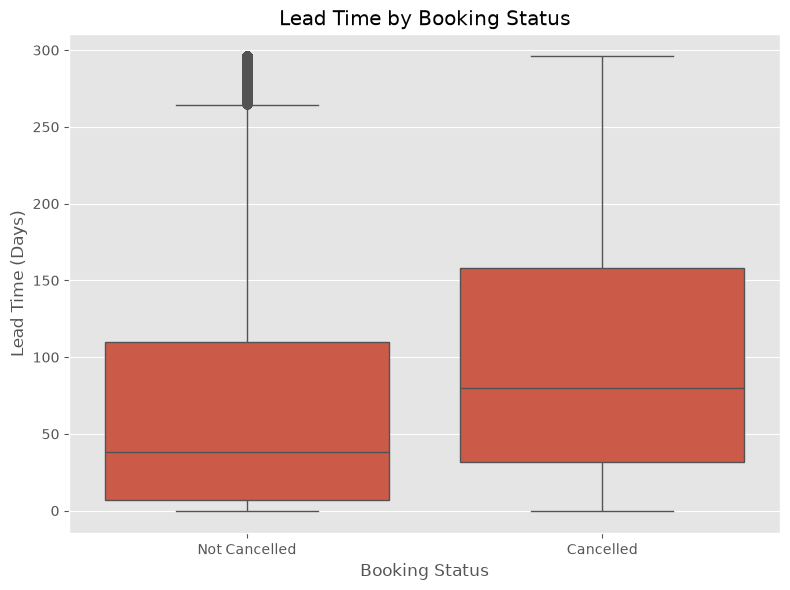

In [150]:
plt.figure(figsize=(8,6))

sns.boxplot(

    data=df,

    x="is_canceled",

    y="lead_time"

)

plt.xticks(

    [0,1],

    ["Not Cancelled","Cancelled"]

)

plt.title("Lead Time by Booking Status")

plt.xlabel("Booking Status")

plt.ylabel("Lead Time (Days)")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/leadtime_vs_cancellation_boxplot.png",

    dpi=300

)

plt.show()

### Violin Plot

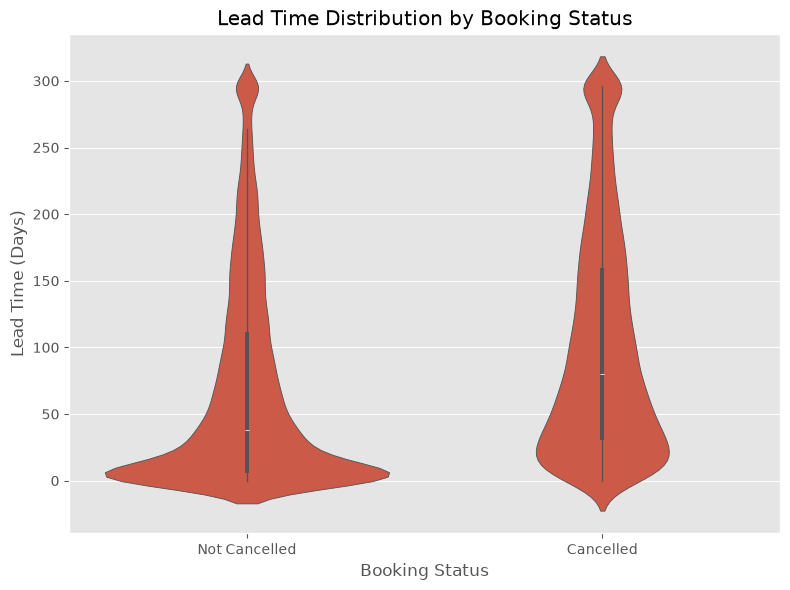

In [151]:
plt.figure(figsize=(8,6))

sns.violinplot(

    data=df,

    x="is_canceled",

    y="lead_time"

)

plt.xticks(

    [0,1],

    ["Not Cancelled","Cancelled"]

)

plt.title("Lead Time Distribution by Booking Status")

plt.xlabel("Booking Status")

plt.ylabel("Lead Time (Days)")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/leadtime_vs_cancellation_violin.png",

    dpi=300

)

plt.show()

### Lead Time Categories vs Cancellation Rate

In [152]:
leadtime_cancel_rate = pd.crosstab(

    df["lead_time_category"],

    df["is_canceled"],

    normalize="index"

) * 100

leadtime_cancel_rate.columns = [

    "Not Cancelled",

    "Cancelled"

]

leadtime_cancel_rate = leadtime_cancel_rate.round(2)

leadtime_cancel_rate

,Not Cancelled,Cancelled
lead_time_category,,
0-7 Days,91.60,8.40
8-30 Days,74.62,25.38
31-90 Days,67.96,32.04
91-180 Days,64.99,35.01
180+ Days,60.26,39.74


### Stacked Bar Chart

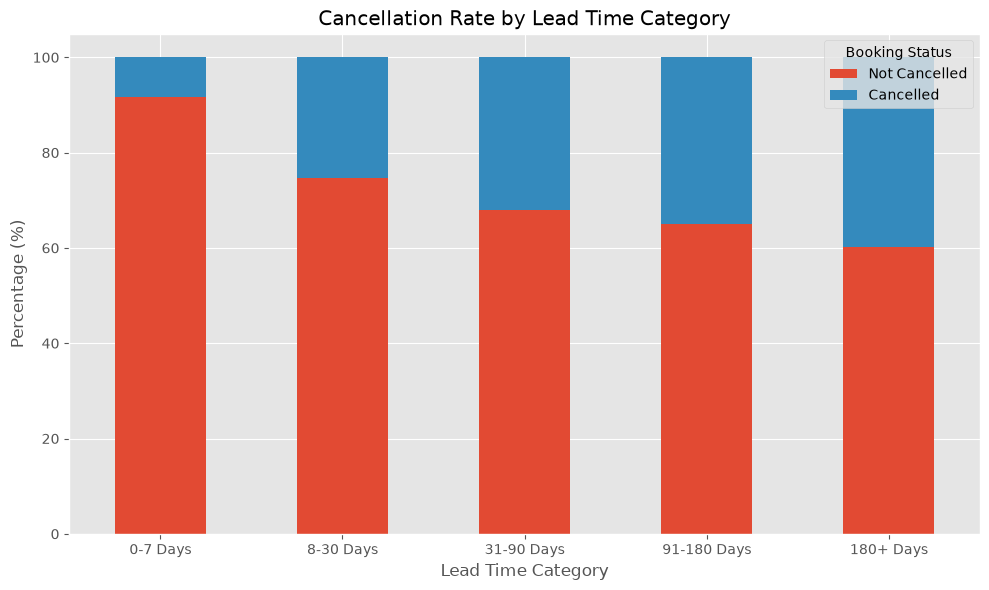

In [153]:
leadtime_cancel_rate.plot(

    kind="bar",

    stacked=True,

    figsize=(10,6)

)

plt.title("Cancellation Rate by Lead Time Category")

plt.xlabel("Lead Time Category")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(title="Booking Status")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/leadtime_category_cancellation.png",

    dpi=300

)

plt.show()

### Scatter Plot

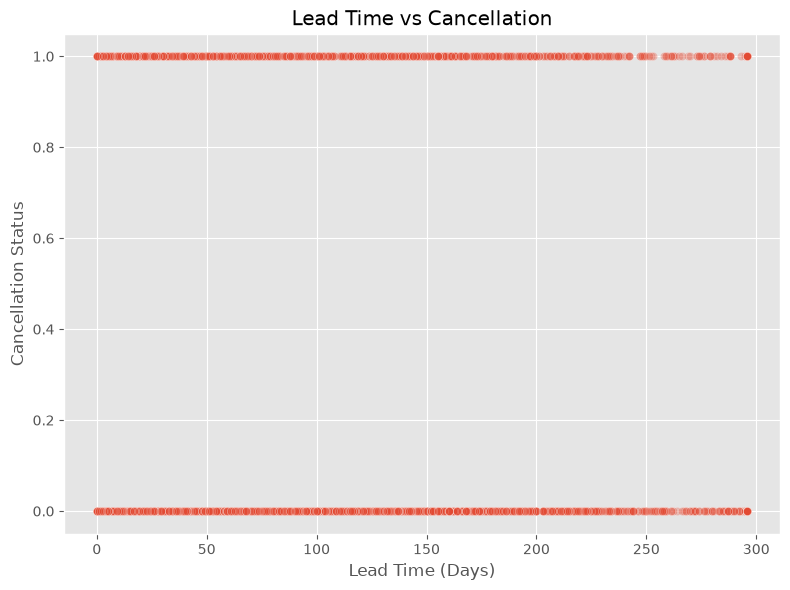

In [154]:
sample_df = df.sample(

    min(5000, len(df)),

    random_state=42

)

plt.figure(figsize=(8,6))

sns.scatterplot(

    data=sample_df,

    x="lead_time",

    y="is_canceled",

    alpha=0.3

)

plt.title("Lead Time vs Cancellation")

plt.xlabel("Lead Time (Days)")

plt.ylabel("Cancellation Status")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/leadtime_vs_cancellation_scatter.png",

    dpi=300

)

plt.show()

In [155]:
leadtime_cancel_rate

,Not Cancelled,Cancelled
lead_time_category,,
0-7 Days,91.60,8.40
8-30 Days,74.62,25.38
31-90 Days,67.96,32.04
91-180 Days,64.99,35.01
180+ Days,60.26,39.74


## Business Interpretation

#### Lead time and cancellation analysis helps identify booking windows associated with higher cancellation risk. If long lead-time bookings cancel more frequently, hotels can introduce targeted confirmation reminders, deposit requirements, or dynamic cancellation policies to reduce revenue loss and improve occupancy forecasting.

## Conclusion

#### The analysis demonstrated how booking lead time influences cancellation behavior. Comparing average lead times, lead time categories, and cancellation rates provides actionable insights for revenue management, demand forecasting, and booking policy optimization,

# Revenue Analysis

### Average Daily Rate (ADR) Analysis

In [156]:
adr_summary = df["average_daily_rate"].describe()

adr_summary

count    87225.000000
mean       105.524569
std         49.032923
min          0.000000
25%         72.250000
50%         98.200000
75%        134.100000
max        226.875000
Name: average_daily_rate, dtype: float64

### Additional Statistics

In [157]:
adr_statistics = pd.DataFrame({

    "Statistic":[

        "Minimum",

        "Maximum",

        "Mean",

        "Median",

        "Standard Deviation",

        "Variance"

    ],

    "Value":[

        round(df["average_daily_rate"].min(),2),

        round(df["average_daily_rate"].max(),2),

        round(df["average_daily_rate"].mean(),2),

        round(df["average_daily_rate"].median(),2),

        round(df["average_daily_rate"].std(),2),

        round(df["average_daily_rate"].var(),2)

    ]

})

adr_statistics

,Statistic,Value
0,Minimum,0.00
1,Maximum,226.88
2,Mean,105.52
3,Median,98.20
4,Standard Deviation,49.03
5,Variance,2404.23


### Histogram

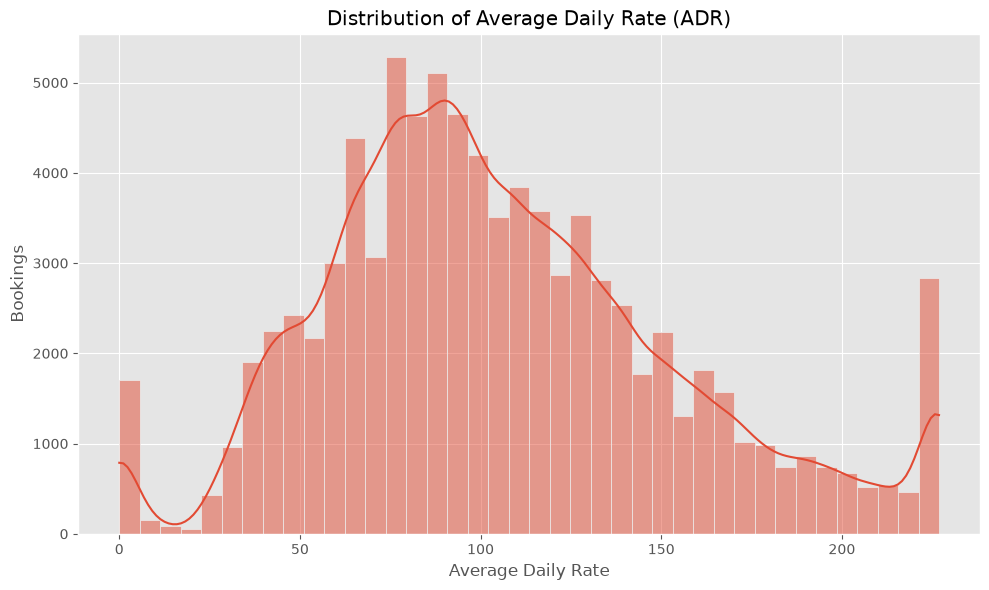

In [158]:
plt.figure(figsize=(10,6))

sns.histplot(

    df["average_daily_rate"],

    bins=40,

    kde=True

)

plt.title("Distribution of Average Daily Rate (ADR)")

plt.xlabel("Average Daily Rate")

plt.ylabel("Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/adr_histogram.png",

    dpi=300

)

plt.show()

### Box Plot

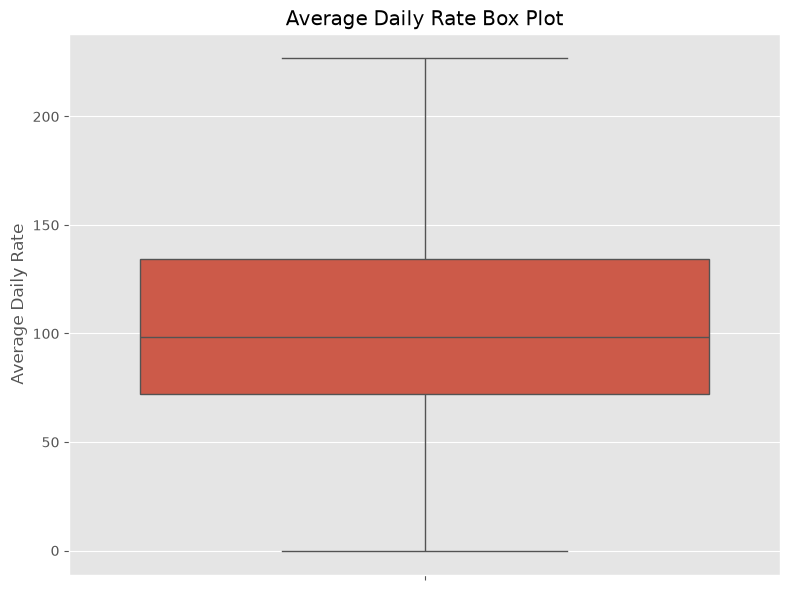

In [159]:
plt.figure(figsize=(8,6))

sns.boxplot(

    y=df["average_daily_rate"]

)

plt.title("Average Daily Rate Box Plot")

plt.ylabel("Average Daily Rate")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/adr_boxplot.png",

    dpi=300

)

plt.show()

### Density Plot

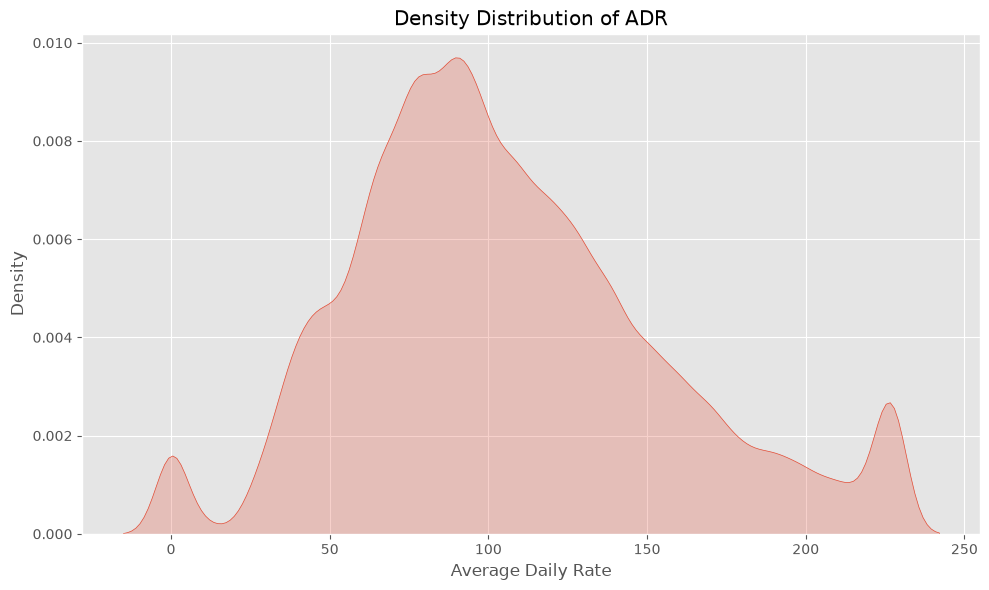

In [160]:
plt.figure(figsize=(10,6))

sns.kdeplot(

    df["average_daily_rate"],

    fill=True

)

plt.title("Density Distribution of ADR")

plt.xlabel("Average Daily Rate")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/adr_density.png",

    dpi=300

)

plt.show()

### Quartile Analysis

In [161]:
adr_quartiles = pd.DataFrame({

    "Quartile":[

        "Q1 (25%)",

        "Median (50%)",

        "Q3 (75%)"

    ],

    "ADR":[

        df["average_daily_rate"].quantile(0.25),

        df["average_daily_rate"].median(),

        df["average_daily_rate"].quantile(0.75)

    ]

})

adr_quartiles

,Quartile,ADR
0,Q1 (25%),72.25
1,Median (50%),98.20
2,Q3 (75%),134.10


### Identify Highest and Lowest ADR

In [162]:
print("Lowest ADR :", round(df["average_daily_rate"].min(),2))

print("Highest ADR :", round(df["average_daily_rate"].max(),2))

print("Average ADR :", round(df["average_daily_rate"].mean(),2))

Lowest ADR : 0.0
Highest ADR : 226.88
Average ADR : 105.52


In [163]:
adr_statistics

,Statistic,Value
0,Minimum,0.00
1,Maximum,226.88
2,Mean,105.52
3,Median,98.20
4,Standard Deviation,49.03
5,Variance,2404.23


## Business Interpretation

#### ADR analysis provides insights into the hotel's pricing strategy and revenue performance. Understanding the distribution of room rates helps management evaluate pricing consistency, identify premium pricing opportunities, detect unusual booking values, and support future pricing optimization decisions.

## Conclusion

#### The Average Daily Rate analysis summarized the hotel's pricing distribution using descriptive statistics and visualizations. These findings establish a baseline for subsequent revenue analyses by hotel type, season, and stay characteristics.

# Revenue by Hotel Type

### Create Estimated Revenue

In [164]:
df["estimated_revenue"] = (

    df["average_daily_rate"]

    * df["total_stay_duration"]

)

### Revenue Summary by Hotel Type

In [165]:
hotel_revenue = (

    df.groupby("hotel")

    .agg(

        Total_Bookings=("hotel", "count"),

        Average_ADR=("average_daily_rate", "mean"),

        Median_ADR=("average_daily_rate", "median"),

        Total_Revenue=("estimated_revenue", "sum"),

        Average_Revenue=("estimated_revenue", "mean")

    )

    .round(2)

    .reset_index()

)

hotel_revenue

,hotel,Total_Bookings,Average_ADR,Median_ADR,Total_Revenue,Average_Revenue
0,City Hotel,53270,110.79,105.3,18572230.20,348.64
1,Resort Hotel,33955,97.26,79.5,15154281.53,446.30


### Bar Chart

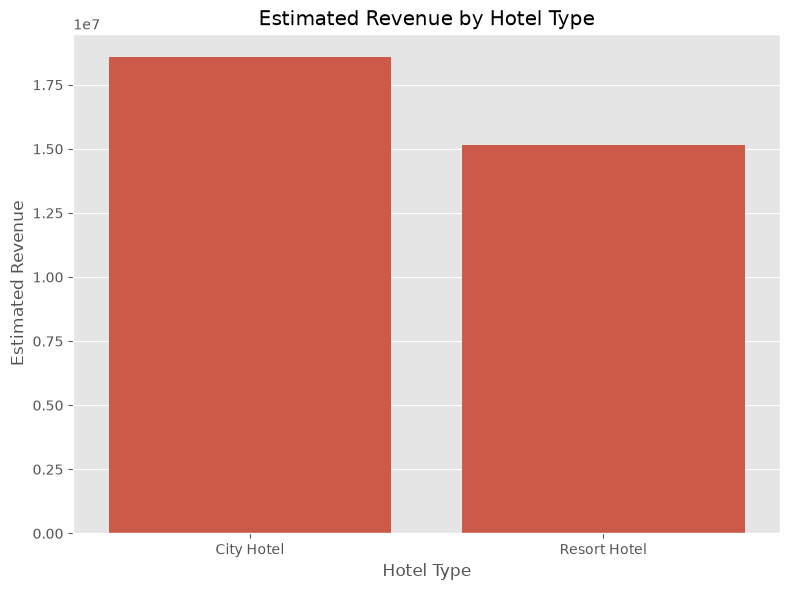

In [166]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=hotel_revenue,

    x="hotel",

    y="Total_Revenue"

)

plt.title("Estimated Revenue by Hotel Type")

plt.xlabel("Hotel Type")

plt.ylabel("Estimated Revenue")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/revenue_hotel_type_bar.png",

    dpi=300

)

plt.show()

### ADR Comparison

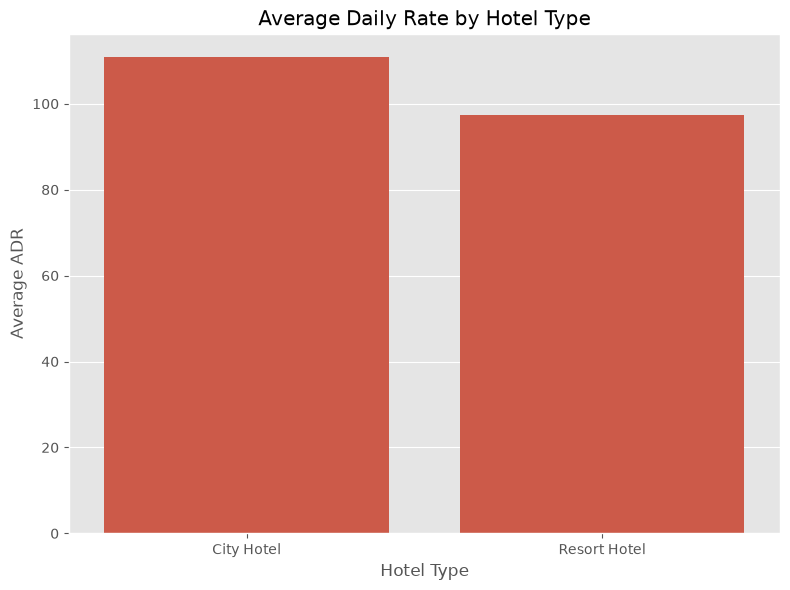

In [167]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=hotel_revenue,

    x="hotel",

    y="Average_ADR"

)

plt.title("Average Daily Rate by Hotel Type")

plt.xlabel("Hotel Type")

plt.ylabel("Average ADR")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/adr_hotel_type_bar.png",

    dpi=300

)

plt.show()

### Box Plot

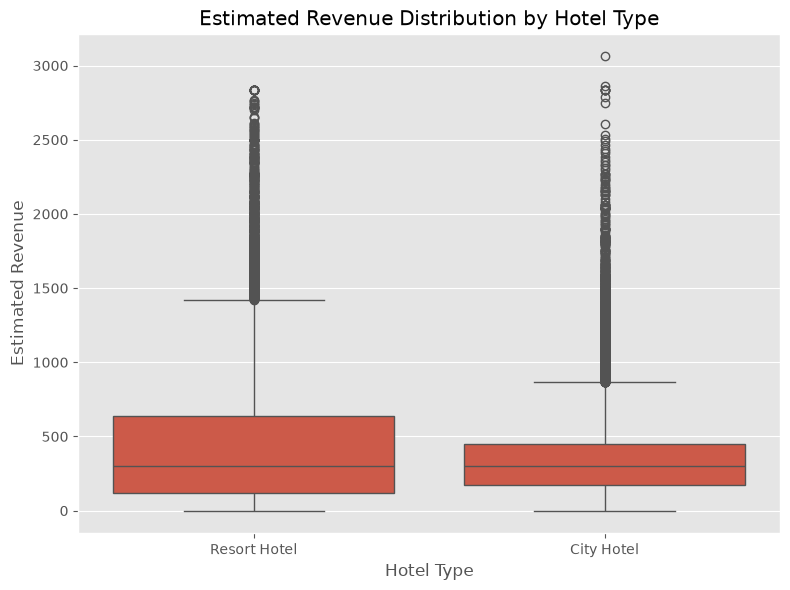

In [168]:
plt.figure(figsize=(8,6))

sns.boxplot(

    data=df,

    x="hotel",

    y="estimated_revenue"

)

plt.title("Estimated Revenue Distribution by Hotel Type")

plt.xlabel("Hotel Type")

plt.ylabel("Estimated Revenue")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/revenue_hotel_type_boxplot.png",

    dpi=300

)

plt.show()

### Revenue Share

In [169]:
hotel_revenue["Revenue_Percentage"] = (

    hotel_revenue["Total_Revenue"]

    / hotel_revenue["Total_Revenue"].sum()

) * 100

hotel_revenue["Revenue_Percentage"] = hotel_revenue["Revenue_Percentage"].round(2)

hotel_revenue

,hotel,Total_Bookings,Average_ADR,Median_ADR,Total_Revenue,Average_Revenue,Revenue_Percentage
0,City Hotel,53270,110.79,105.3,18572230.20,348.64,55.07
1,Resort Hotel,33955,97.26,79.5,15154281.53,446.30,44.93


### Pie Chart

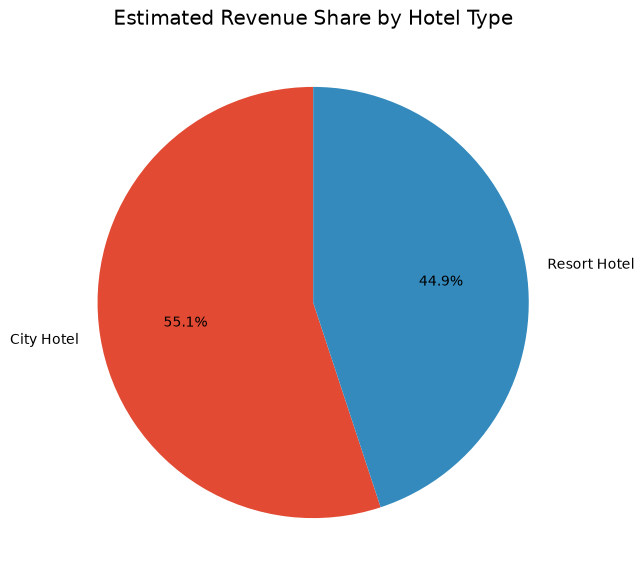

In [170]:
plt.figure(figsize=(7,7))

plt.pie(

    hotel_revenue["Total_Revenue"],

    labels=hotel_revenue["hotel"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Estimated Revenue Share by Hotel Type")

plt.savefig(

    "../figures/phase_06/revenue_hotel_type_pie.png",

    dpi=300

)

plt.show()

In [171]:
hotel_revenue

,hotel,Total_Bookings,Average_ADR,Median_ADR,Total_Revenue,Average_Revenue,Revenue_Percentage
0,City Hotel,53270,110.79,105.3,18572230.20,348.64,55.07
1,Resort Hotel,33955,97.26,79.5,15154281.53,446.30,44.93


## Business Interpretation

#### Revenue analysis by hotel type compares the financial performance of City Hotels and Resort Hotels using estimated booking revenue. The analysis helps management identify which hotel type contributes more to overall revenue, evaluate pricing strategies, and make informed decisions regarding resource allocation, marketing investment, and future expansion.

## Conclusion

#### Revenue comparison between City Hotels and Resort Hotels highlighted differences in pricing, booking volume, and estimated revenue generation. These insights support strategic decision-making related to pricing optimization, business growth, and operational planning.

# Revenue by Season

### Revenue Summary by Season

In [172]:
season_revenue = (

    df.groupby("season")

    .agg(

        Total_Bookings=("season", "count"),

        Average_ADR=("average_daily_rate", "mean"),

        Total_Revenue=("estimated_revenue", "sum"),

        Average_Revenue=("estimated_revenue", "mean")

    )

    .round(2)

    .reset_index()

)

season_order = [

    "Spring",

    "Summer",

    "Autumn",

    "Winter"

]

season_revenue["season"] = pd.Categorical(

    season_revenue["season"],

    categories=season_order,

    ordered=True

)

season_revenue = season_revenue.sort_values("season")

season_revenue

,season,Total_Bookings,Average_ADR,Total_Revenue,Average_Revenue
1,Spring,23732,99.00,7876725.29,331.90
2,Summer,29037,135.04,16137218.44,555.75
0,Autumn,18576,93.42,5869548.36,315.97
3,Winter,15880,75.45,3843019.65,242.00


### Revenue Percentage

In [173]:
season_revenue["Revenue_Percentage"] = (

    season_revenue["Total_Revenue"]

    / season_revenue["Total_Revenue"].sum()

) * 100

season_revenue["Revenue_Percentage"] = (

    season_revenue["Revenue_Percentage"]

    .round(2)

)

season_revenue

,season,Total_Bookings,Average_ADR,Total_Revenue,Average_Revenue,Revenue_Percentage
1,Spring,23732,99.00,7876725.29,331.90,23.35
2,Summer,29037,135.04,16137218.44,555.75,47.85
0,Autumn,18576,93.42,5869548.36,315.97,17.40
3,Winter,15880,75.45,3843019.65,242.00,11.39


### Bar Chart

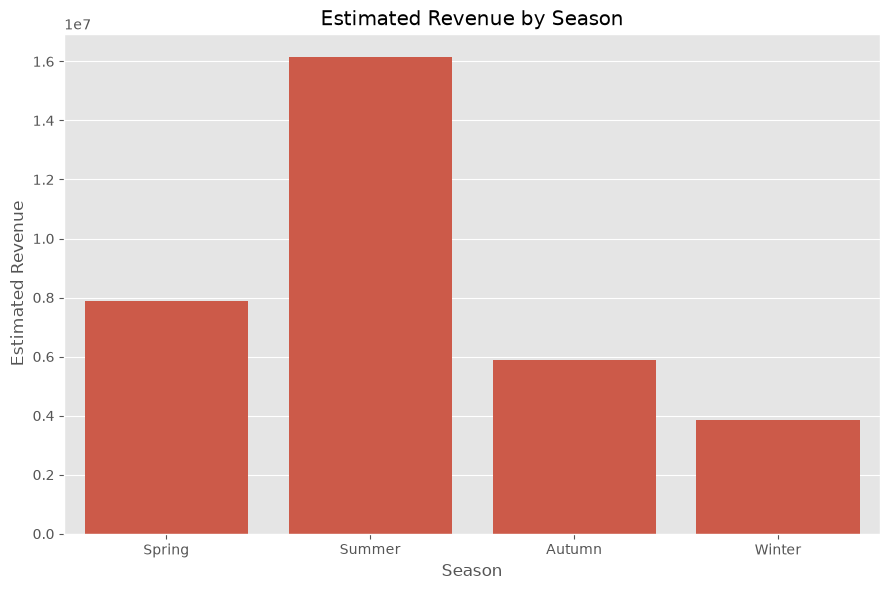

In [174]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=season_revenue,

    x="season",

    y="Total_Revenue"

)

plt.title("Estimated Revenue by Season")

plt.xlabel("Season")

plt.ylabel("Estimated Revenue")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/revenue_by_season_bar.png",

    dpi=300

)

plt.show()

### Average ADR by Season

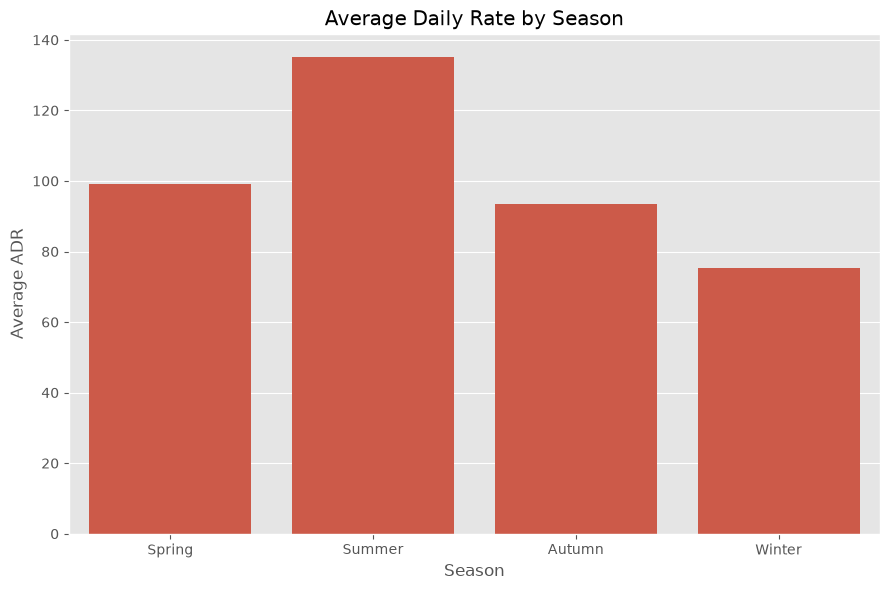

In [175]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=season_revenue,

    x="season",

    y="Average_ADR"

)

plt.title("Average Daily Rate by Season")

plt.xlabel("Season")

plt.ylabel("Average ADR")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/adr_by_season_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

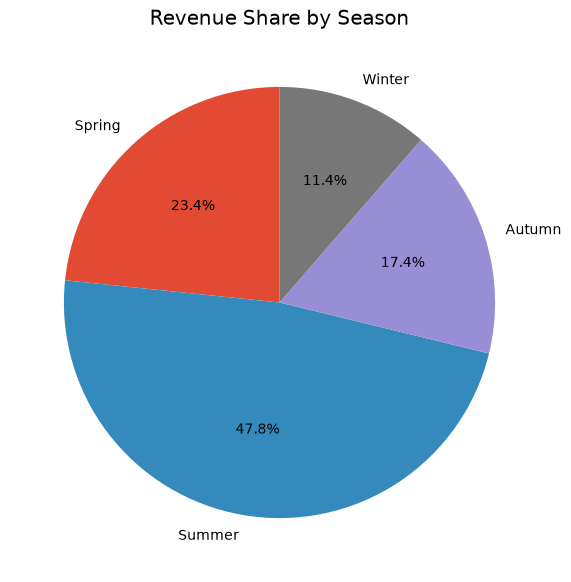

In [176]:
plt.figure(figsize=(7,7))

plt.pie(

    season_revenue["Total_Revenue"],

    labels=season_revenue["season"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Revenue Share by Season")

plt.savefig(

    "../figures/phase_06/revenue_by_season_pie.png",

    dpi=300

)

plt.show()

### Box Plot

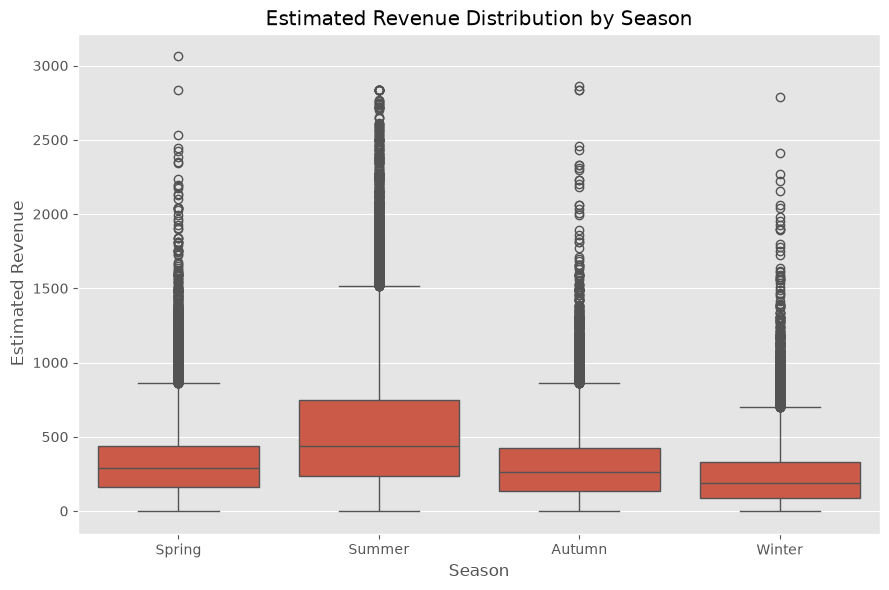

In [177]:
plt.figure(figsize=(9,6))

sns.boxplot(

    data=df,

    x="season",

    y="estimated_revenue",

    order=season_order

)

plt.title("Estimated Revenue Distribution by Season")

plt.xlabel("Season")

plt.ylabel("Estimated Revenue")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/revenue_by_season_boxplot.png",

    dpi=300

)

plt.show()

### Highest Revenue Season

In [178]:
highest_revenue = season_revenue.loc[

    season_revenue["Total_Revenue"].idxmax()

]

print("Highest Revenue Season :", highest_revenue["season"])

print("Estimated Revenue :", round(highest_revenue["Total_Revenue"],2))

Highest Revenue Season : Summer
Estimated Revenue : 16137218.44


In [179]:
season_revenue

,season,Total_Bookings,Average_ADR,Total_Revenue,Average_Revenue,Revenue_Percentage
1,Spring,23732,99.00,7876725.29,331.90,23.35
2,Summer,29037,135.04,16137218.44,555.75,47.85
0,Autumn,18576,93.42,5869548.36,315.97,17.40
3,Winter,15880,75.45,3843019.65,242.00,11.39


## Business Interpretation

#### Seasonal revenue analysis helps identify peak and off-peak earning periods. Understanding how revenue changes throughout the year enables hotels to optimize pricing strategies, allocate resources efficiently, schedule maintenance during low-demand periods, and design targeted seasonal promotions.

## Conclusion

#### Revenue analysis by season highlighted the contribution of each season to overall estimated revenue. The results provide valuable insights for seasonal pricing, demand forecasting, operational planning, and long-term revenue optimization

# Weekend vs Weekday Revenue

### Create Revenue Columns

In [180]:
df["weekday_revenue"] = (

    df["average_daily_rate"]

    * df["stays_in_week_nights"]

)

df["weekend_revenue"] = (

    df["average_daily_rate"]

    * df["stays_in_weekend_nights"]

)

### Revenue Summary

In [181]:
revenue_summary = pd.DataFrame({

    "Stay Type":[

        "Weekday",

        "Weekend"

    ],

    "Total Revenue":[

        df["weekday_revenue"].sum(),

        df["weekend_revenue"].sum()

    ],

    "Average Revenue":[

        df["weekday_revenue"].mean(),

        df["weekend_revenue"].mean()

    ]

})

revenue_summary = revenue_summary.round(2)

revenue_summary

,Stay Type,Total Revenue,Average Revenue
0,Weekday,24323114.16,278.85
1,Weekend,9403397.57,107.81


### Revenue Percentage

In [182]:
revenue_summary["Revenue Percentage"] = (

    revenue_summary["Total Revenue"]

    / revenue_summary["Total Revenue"].sum()

) * 100

revenue_summary["Revenue Percentage"] = (

    revenue_summary["Revenue Percentage"]

    .round(2)

)

revenue_summary

,Stay Type,Total Revenue,Average Revenue,Revenue Percentage
0,Weekday,24323114.16,278.85,72.12
1,Weekend,9403397.57,107.81,27.88


### Bar Chart

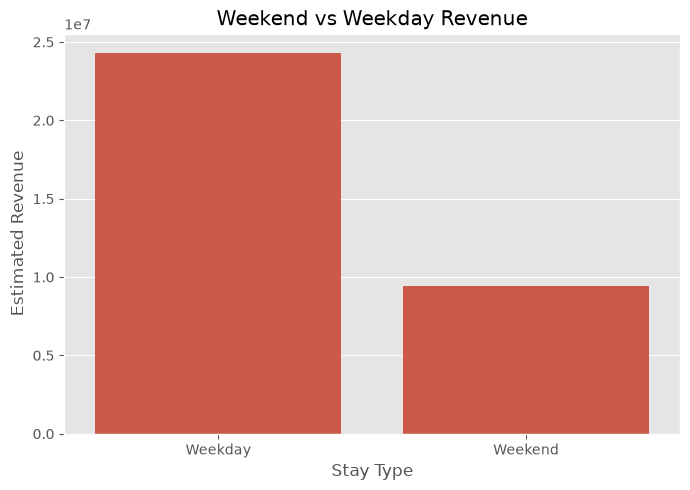

In [183]:
plt.figure(figsize=(7,5))

sns.barplot(

    data=revenue_summary,

    x="Stay Type",

    y="Total Revenue"

)

plt.title("Weekend vs Weekday Revenue")

plt.xlabel("Stay Type")

plt.ylabel("Estimated Revenue")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/weekend_vs_weekday_revenue_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

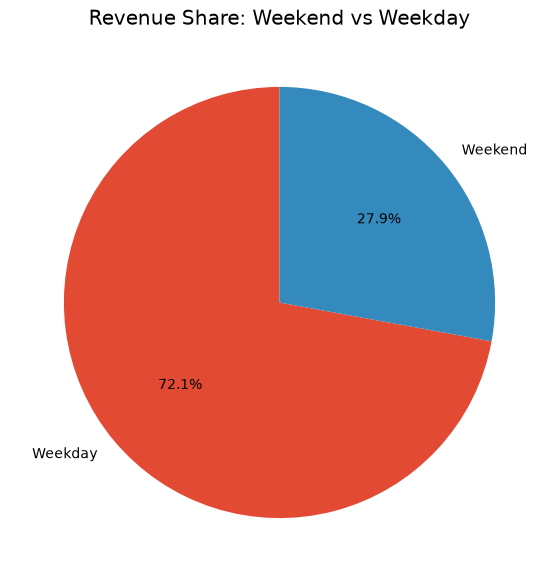

In [184]:
plt.figure(figsize=(7,7))

plt.pie(

    revenue_summary["Total Revenue"],

    labels=revenue_summary["Stay Type"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Revenue Share: Weekend vs Weekday")

plt.savefig(

    "../figures/phase_06/weekend_vs_weekday_revenue_pie.png",

    dpi=300

)

plt.show()

### Box Plot

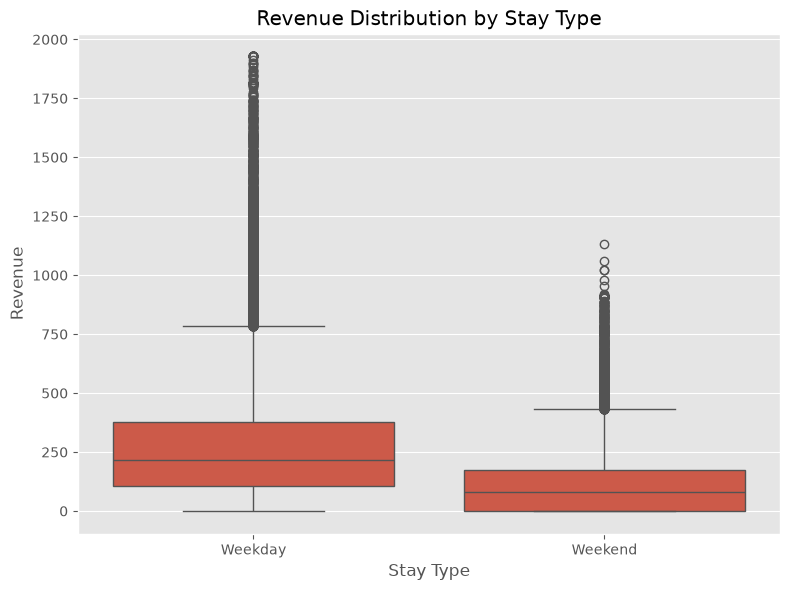

In [185]:
plot_df = pd.DataFrame({

    "Revenue": pd.concat(

        [

            df["weekday_revenue"],

            df["weekend_revenue"]

        ],

        ignore_index=True

    ),

    "Stay Type":

        ["Weekday"] * len(df)

        +

        ["Weekend"] * len(df)

})

plt.figure(figsize=(8,6))

sns.boxplot(

    data=plot_df,

    x="Stay Type",

    y="Revenue"

)

plt.title("Revenue Distribution by Stay Type")

plt.xlabel("Stay Type")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/weekend_vs_weekday_revenue_boxplot.png",

    dpi=300

)

plt.show()

### KPI Summary

In [186]:
print(

    "Weekday Revenue :",

    round(df["weekday_revenue"].sum(),2)

)

print(

    "Weekend Revenue :",

    round(df["weekend_revenue"].sum(),2)

)

print(

    "Difference :",

    round(

        df["weekday_revenue"].sum()

        -

        df["weekend_revenue"].sum(),

        2

    )

)

Weekday Revenue : 24323114.16
Weekend Revenue : 9403397.57
Difference : 14919716.6


In [187]:
revenue_summary

,Stay Type,Total Revenue,Average Revenue,Revenue Percentage
0,Weekday,24323114.16,278.85,72.12
1,Weekend,9403397.57,107.81,27.88


## Business Interpretation

#### Comparing weekday and weekend revenue helps evaluate guest stay patterns and pricing effectiveness. If weekday revenue dominates, hotels may focus on maintaining business travel demand. If weekend revenue is comparatively high, premium pricing and leisure-focused promotional campaigns can be strengthened to maximize profitability.

## Conclusion

#### Weekend versus weekday revenue analysis compared estimated revenue generated from different stay types. The findings provide valuable insights into guest behavior, pricing effectiveness, and revenue optimization opportunities across the booking period.

# Stay Analysis

### Stay Duration Analysis

In [188]:
stay_summary = df["total_stay_duration"].describe()

stay_summary

count    87225.000000
mean         3.575947
std          2.448157
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         13.500000
Name: total_stay_duration, dtype: float64

### Additional Statistics

In [189]:
stay_statistics = pd.DataFrame({

    "Statistic":[

        "Minimum",

        "Maximum",

        "Mean",

        "Median",

        "Standard Deviation"

    ],

    "Value":[

        df["total_stay_duration"].min(),

        df["total_stay_duration"].max(),

        round(df["total_stay_duration"].mean(),2),

        df["total_stay_duration"].median(),

        round(df["total_stay_duration"].std(),2)

    ]

})

stay_statistics

,Statistic,Value
0,Minimum,0.00
1,Maximum,13.50
2,Mean,3.58
3,Median,3.00
4,Standard Deviation,2.45


### Histogram

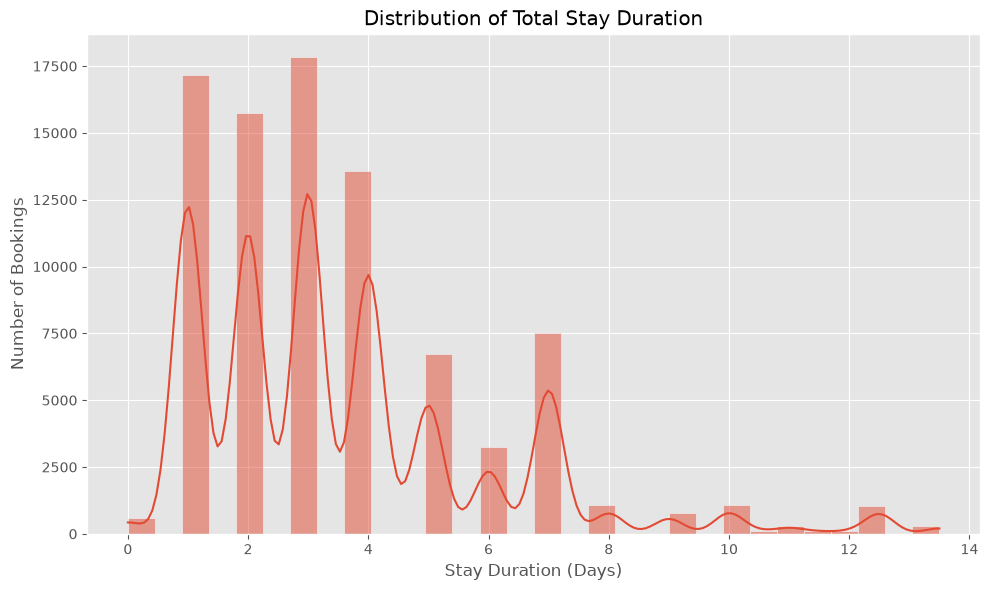

In [190]:
plt.figure(figsize=(10,6))

sns.histplot(

    data=df,

    x="total_stay_duration",

    bins=30,

    kde=True

)

plt.title("Distribution of Total Stay Duration")

plt.xlabel("Stay Duration (Days)")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/stay_duration_histogram.png",

    dpi=300

)

plt.show()

### Box Plot

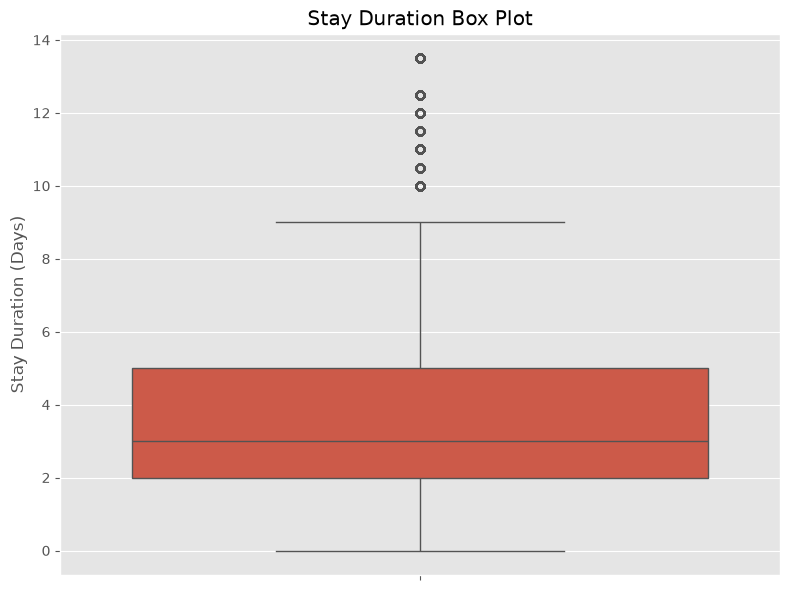

In [191]:
plt.figure(figsize=(8,6))

sns.boxplot(

    y=df["total_stay_duration"]

)

plt.title("Stay Duration Box Plot")

plt.ylabel("Stay Duration (Days)")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/stay_duration_boxplot.png",

    dpi=300

)

plt.show()

### Stay Duration Categories

In [192]:
bins = [0, 2, 5, 7, 14, df["total_stay_duration"].max()]

labels = [

    "1-2 Days",

    "3-5 Days",

    "6-7 Days",

    "8-14 Days",

    "15+ Days"

]

df["stay_category"] = pd.cut(

    df["total_stay_duration"],

    bins=bins,

    labels=labels,

    include_lowest=True

)

ValueError: bins must increase monotonically.

### Category Summary

In [193]:
stay_category_summary = (

    df["stay_category"]

    .value_counts()

    .sort_index()

    .reset_index()

)

stay_category_summary.columns = [

    "Stay Category",

    "Bookings"

]

stay_category_summary

KeyError: 'stay_category'

### Bar Chart

In [194]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=stay_category_summary,

    x="Stay Category",

    y="Bookings"

)

plt.title("Bookings by Stay Duration Category")

plt.xlabel("Stay Duration")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/stay_category_bar.png",

    dpi=300

)

plt.show()

NameError: name 'stay_category_summary' is not defined

<Figure size 900x600 with 0 Axes>

In [195]:
stay_category_summary

NameError: name 'stay_category_summary' is not defined

## Business Interpretation

#### Stay duration analysis provides insights into how long guests typically remain at the hotel. Understanding stay patterns helps optimize room allocation, housekeeping schedules, occupancy forecasting, pricing strategies, and promotional offers for both short-term and long-term guests.

## Conclusion

#### Stay duration analysis summarized guest booking lengths using descriptive statistics and categorized stay durations. The findings help hotel management understand customer stay behavior and support operational planning and revenue optimization.

# Guest Demographics Analysis

In [196]:
guest_demographics = df[

    ["adults", "children", "babies"]

].describe()

guest_demographics

,adults,children,babies
count,87225.0,87225.0,87225.0
mean,2.0,0.0,0.0
std,0.0,0.0,0.0
min,2.0,0.0,0.0
25%,2.0,0.0,0.0
50%,2.0,0.0,0.0
75%,2.0,0.0,0.0
max,2.0,0.0,0.0


### Average Number of Guests

In [197]:
average_guests = pd.DataFrame({

    "Guest Type":[

        "Adults",

        "Children",

        "Babies"

    ],

    "Average Count":[

        round(df["adults"].mean(),2),

        round(df["children"].mean(),2),

        round(df["babies"].mean(),2)

    ]

})

average_guests

,Guest Type,Average Count
0,Adults,2.0
1,Children,0.0
2,Babies,0.0


### Total Number of Guests

In [198]:
total_guests = pd.DataFrame({

    "Guest Type":[

        "Adults",

        "Children",

        "Babies"

    ],

    "Total Count":[

        df["adults"].sum(),

        df["children"].sum(),

        df["babies"].sum()

    ]

})

total_guests

,Guest Type,Total Count
0,Adults,174450.0
1,Children,0.0
2,Babies,0.0


### Bar Chart

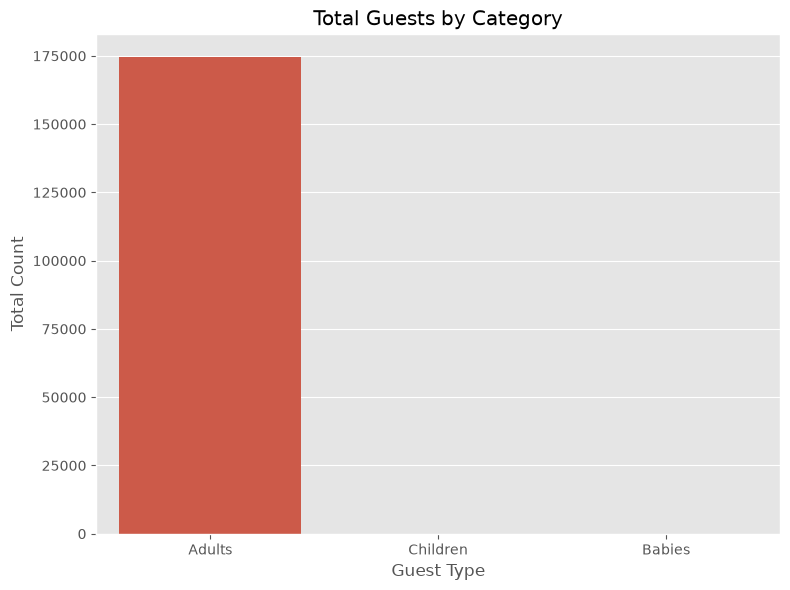

In [199]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=total_guests,

    x="Guest Type",

    y="Total Count"

)

plt.title("Total Guests by Category")

plt.xlabel("Guest Type")

plt.ylabel("Total Count")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/guest_demographics_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

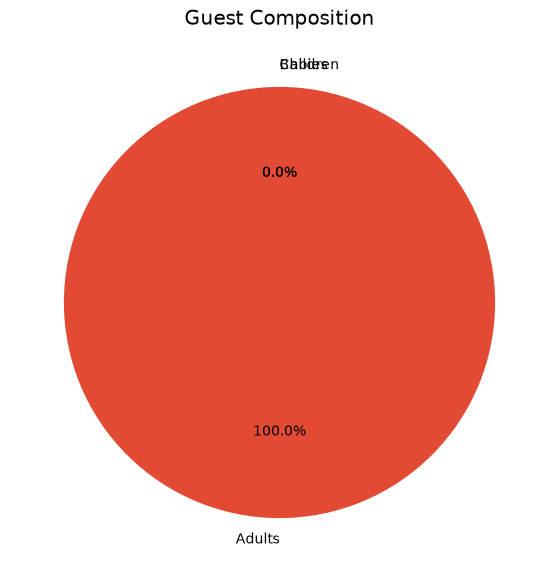

In [200]:
plt.figure(figsize=(7,7))

plt.pie(

    total_guests["Total Count"],

    labels=total_guests["Guest Type"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Guest Composition")

plt.savefig(

    "../figures/phase_06/guest_demographics_pie.png",

    dpi=300

)

plt.show()

### Distribution of Adults

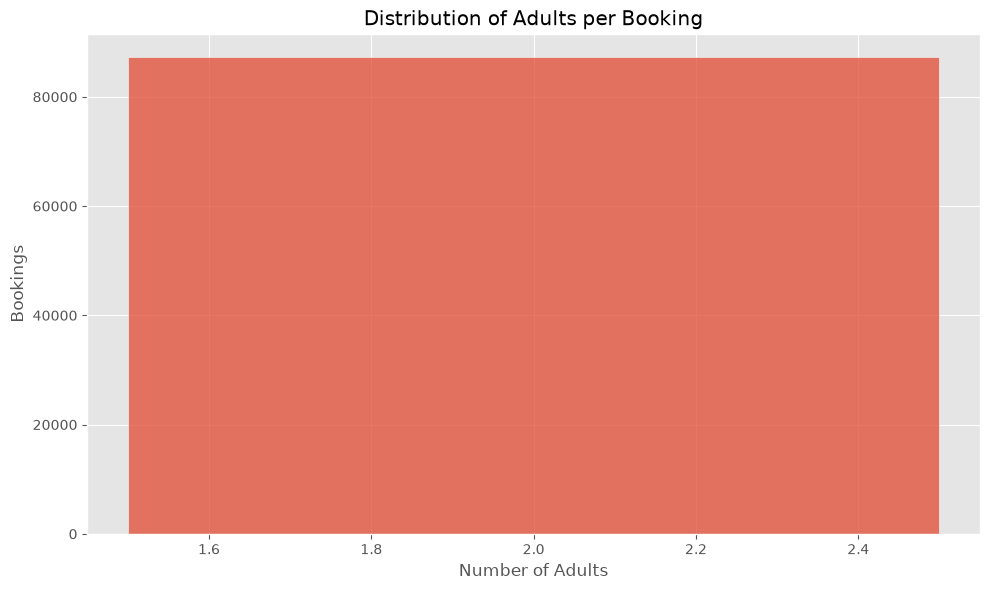

In [201]:
plt.figure(figsize=(10,6))

sns.histplot(

    data=df,

    x="adults",

    discrete=True

)

plt.title("Distribution of Adults per Booking")

plt.xlabel("Number of Adults")

plt.ylabel("Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/adults_distribution.png",

    dpi=300

)

plt.show()

### Distribution of Children

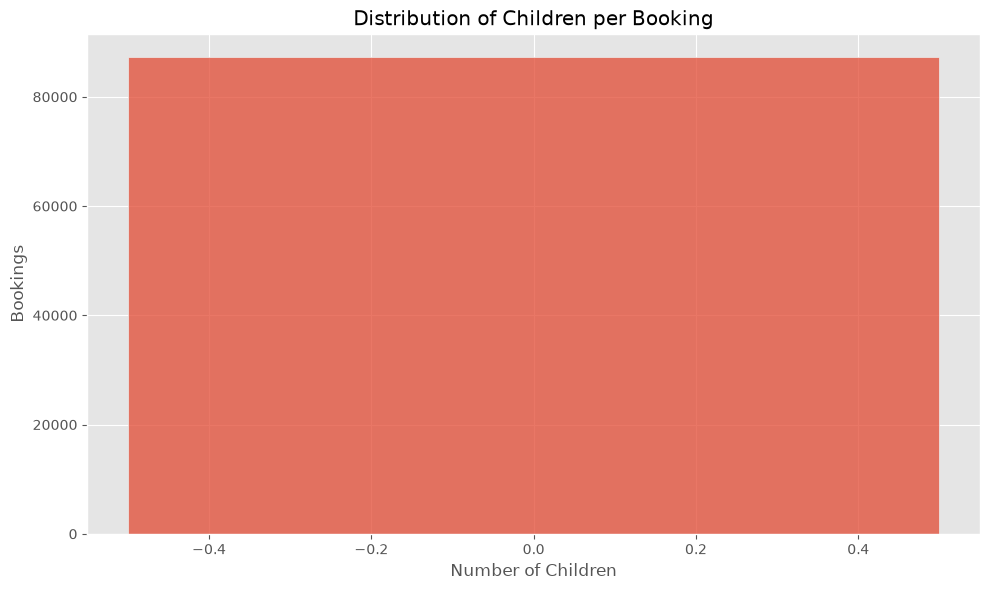

In [202]:
plt.figure(figsize=(10,6))

sns.histplot(

    data=df,

    x="children",

    discrete=True

)

plt.title("Distribution of Children per Booking")

plt.xlabel("Number of Children")

plt.ylabel("Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/children_distribution.png",

    dpi=300

)

plt.show()

### Distribution of Babies

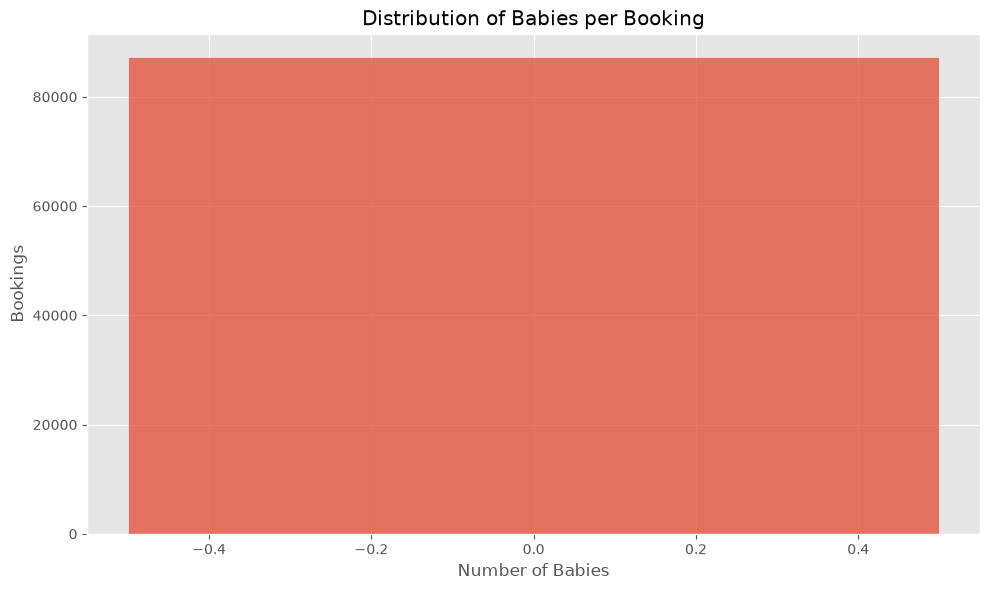

In [203]:
plt.figure(figsize=(10,6))

sns.histplot(

    data=df,

    x="babies",

    discrete=True

)

plt.title("Distribution of Babies per Booking")

plt.xlabel("Number of Babies")

plt.ylabel("Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/babies_distribution.png",

    dpi=300

)

plt.show()

In [204]:
average_guests

,Guest Type,Average Count
0,Adults,2.0
1,Children,0.0
2,Babies,0.0


In [205]:
total_guests

,Guest Type,Total Count
0,Adults,174450.0
1,Children,0.0
2,Babies,0.0


## Business Interpretation

#### Guest demographics analysis provides insights into the composition of hotel bookings. Understanding whether guests primarily travel as couples, families, or larger groups helps hotels optimize room configurations, family-friendly amenities, dining services, and targeted marketing campaigns.

## Conclusion

#### Guest demographics analysis examined the distribution of adults, children, and babies across bookings. The findings provide valuable insights into customer composition, enabling hotels to improve service offerings, room planning, and customer experience.

# Special Requests Analysis

In [206]:
special_request_summary = df["total_of_special_requests"].describe()

special_request_summary

count    87225.000000
mean         0.698917
std          0.832058
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: total_of_special_requests, dtype: float64

## Frequency Distribution

In [207]:
special_request_frequency = (

    df["total_of_special_requests"]

    .value_counts()

    .sort_index()

    .reset_index()

)

special_request_frequency.columns = [

    "Number of Requests",

    "Bookings"

]

special_request_frequency

,Number of Requests,Bookings
0,0,43788
1,1,28973
2,2,11794
3,3,2314
4,4,320
5,5,36


### Percentage Distribution

In [208]:
special_request_frequency["Percentage"] = (

    special_request_frequency["Bookings"]

    / special_request_frequency["Bookings"].sum()

) * 100

special_request_frequency["Percentage"] = (

    special_request_frequency["Percentage"]

    .round(2)

)

special_request_frequency

,Number of Requests,Bookings,Percentage
0,0,43788,50.20
1,1,28973,33.22
2,2,11794,13.52
3,3,2314,2.65
4,4,320,0.37
5,5,36,0.04


### Bar Chart

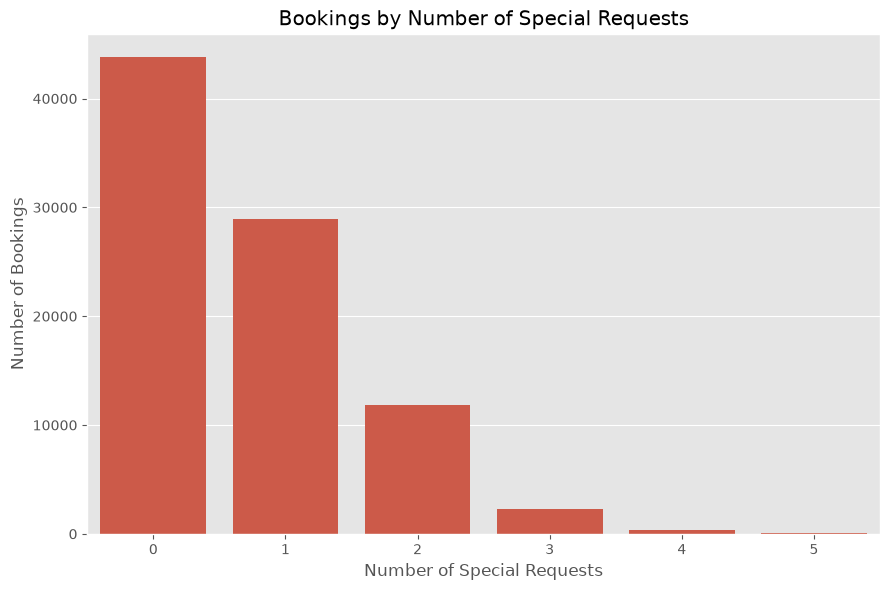

In [209]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=special_request_frequency,

    x="Number of Requests",

    y="Bookings"

)

plt.title("Bookings by Number of Special Requests")

plt.xlabel("Number of Special Requests")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/special_requests_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

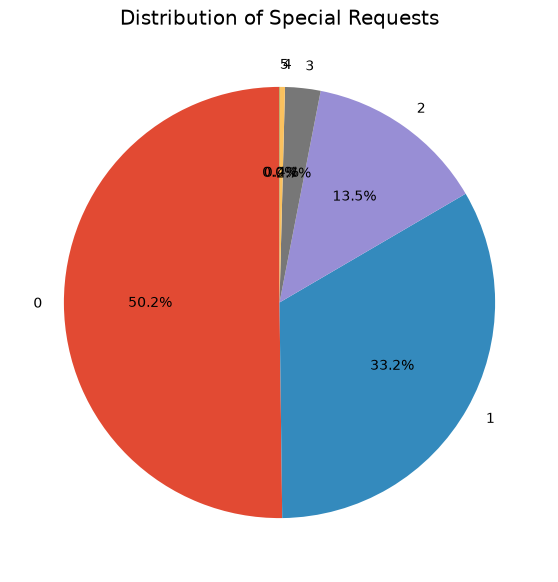

In [210]:
plt.figure(figsize=(7,7))

plt.pie(

    special_request_frequency["Bookings"],

    labels=special_request_frequency["Number of Requests"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Distribution of Special Requests")

plt.savefig(

    "../figures/phase_06/special_requests_pie.png",

    dpi=300

)

plt.show()

### Special Requests vs Cancellation

In [211]:
request_cancellation = pd.crosstab(

    df["total_of_special_requests"],

    df["is_canceled"],

    normalize="index"

) * 100

request_cancellation.columns = [

    "Not Cancelled",

    "Cancelled"

]

request_cancellation = request_cancellation.round(2)

request_cancellation

,Not Cancelled,Cancelled
total_of_special_requests,,
0,66.75,33.25
1,77.57,22.43
2,78.68,21.32
3,82.89,17.11
4,89.38,10.62
5,94.44,5.56


### Stacked Bar Chart

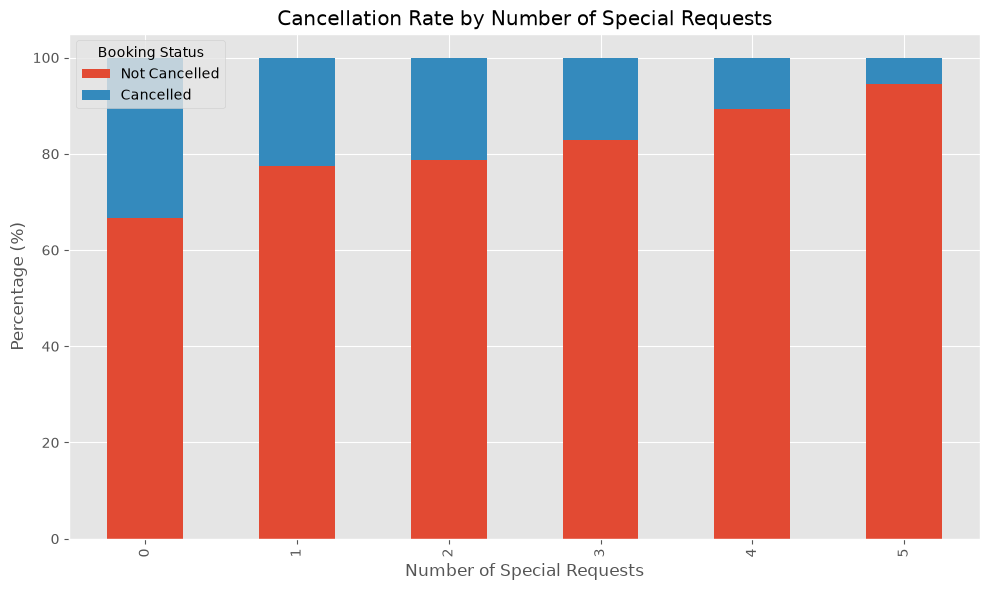

In [212]:
request_cancellation.plot(

    kind="bar",

    stacked=True,

    figsize=(10,6)

)

plt.title("Cancellation Rate by Number of Special Requests")

plt.xlabel("Number of Special Requests")

plt.ylabel("Percentage (%)")

plt.legend(title="Booking Status")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/special_requests_cancellation.png",

    dpi=300

)

plt.show()

In [213]:
special_request_frequency

,Number of Requests,Bookings,Percentage
0,0,43788,50.20
1,1,28973,33.22
2,2,11794,13.52
3,3,2314,2.65
4,4,320,0.37
5,5,36,0.04


In [214]:
request_cancellation

,Not Cancelled,Cancelled
total_of_special_requests,,
0,66.75,33.25
1,77.57,22.43
2,78.68,21.32
3,82.89,17.11
4,89.38,10.62
5,94.44,5.56


## Business Interpretation

#### Special request analysis provides insights into customer preferences and engagement levels. Guests who make multiple requests may be more committed to their bookings and have higher service expectations. Understanding these patterns enables hotels to improve personalized services, allocate resources efficiently, and enhance customer satisfaction.

## Conclusion

#### Special requests analysis examined the frequency of guest requests and their relationship with booking cancellations. The findings provide valuable insights into customer engagement, service personalization, and operational planning, supporting improved guest experiences and more informed management decisions.